In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
from scipy import stats

In [2]:
caminho_arquivo = './dados/MICRODADOS_ENEM_2019.csv'
data = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';')
num_columns = data.shape[1]
num_rows = data.shape[0]
print(f"Número de colunas: {num_columns}")
print(f"Número de linhas: {num_rows}")
data.head()

Número de colunas: 76
Número de linhas: 5095171


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,190001595656,2019,13,M,1,3,1,1,11,1,...,A,A,A,A,A,A,C,A,C,B
1,190001421546,2019,8,M,1,1,1,1,5,1,...,A,A,A,B,A,A,E,A,A,B
2,190001133210,2019,13,F,1,3,1,1,13,1,...,A,A,A,B,A,A,C,A,A,B
3,190001199383,2019,10,F,1,1,1,1,4,1,...,A,A,A,C,A,B,D,A,B,B
4,190001237802,2019,7,F,1,1,1,1,4,1,...,B,A,A,B,A,A,C,B,B,B


In [ ]:
#Funções

#função tratar nulos
def tratarNulos(dados):
    dataset = dados.copy()  # evita problemas de referência
    
    # Colunas numéricas que representam categorias
    colunas_categoricas_numericas = [
        'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA',
        'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU',
        'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC','Q006',
        'Q007','Q008','Q009','Q010','Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018','Q019'
    ]
    
    for col in dataset.columns:
        if dataset[col].isnull().any():  # só trata se houver nulos
            if col in colunas_categoricas_numericas:
                # Para categóricas → moda
                moda = dataset[col].mode()
                if not moda.empty:
                    dataset[col] = dataset[col].fillna(moda.iloc[0])
            else:
                # Para numéricas contínuas → média
                media = dataset[col].mean()
                dataset[col] = dataset[col].fillna(media)
    
    return dataset



#Função analisar importância das features de forma agregada
def analisar_importancia_features_agregada(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância das features de um modelo DecisionTreeClassifier,
    somando as importâncias das dummies das features categóricas.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - categoricas: lista de colunas categóricas originais
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_agregado: DataFrame com importância agregada por feature
    """

    categoricas = ['TP_SEXO', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019']
    # Extrair nomes das features pós-transformação
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    
    # Importâncias
    importances = clf.feature_importances_
    
    # Criar DataFrame
    df = pd.DataFrame({
        'feature_expandida': nomes_features,
        'importancia': importances
    })
    
    # Inicializar coluna de feature original
    df['feature_original'] = df['feature_expandida']
    
    # Mapear dummies categóricas para a feature original
    for cat in categoricas:
        mask = df['feature_expandida'].str.contains(f"__{cat}_")
        df.loc[mask, 'feature_original'] = cat
    
    # Agregar importâncias por feature original
    df_agregado = df.groupby('feature_original')['importancia'].sum().sort_values(ascending=False)
    
    # Filtrar top_n se necessário
    if top_n:
        df_agregado = df_agregado.head(top_n)
    
    # Print em texto
    print("Importância das features (agregada):")
    for feat, imp in df_agregado.items():
        print(f"Feature {feat}: {imp:.4f}")
    
    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_agregado.index, df_agregado.values)   # <-- barras horizontais
    plt.xlabel("Importância")                         # título do eixo X
    plt.ylabel("Features")                            # título do eixo Y
    plt.title(f"Importância das Features {titulo} (DecisionTreeClassifier)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return df_agregado


#Função analisar features de forma individual
def analisar_importancia_features(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância individual das features (sem agregação) 
    de um modelo DecisionTreeClassifier treinado dentro de um pipeline.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_importancias: DataFrame com importâncias individuais
    """

    # Extrair nomes das features após o pré-processamento
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()

    # Pegar as importâncias
    importances = clf.feature_importances_

    # Criar DataFrame
    df_importancias = pd.DataFrame({
        'feature': nomes_features,
        'importancia': importances
    }).sort_values(by='importancia', ascending=False)

    # Filtrar top_n se solicitado
    if top_n:
        df_importancias = df_importancias.head(top_n)

    # Print simples
    print("Importância das features (sem agregação):")
    for feat, imp in zip(df_importancias['feature'], df_importancias['importancia']):
        print(f"{feat}: {imp:.4f}")

    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_importancias['feature'], df_importancias['importancia'])
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.title(f"Importância Individual das Features {titulo}(DecisionTreeClassifier)")
    plt.gca().invert_yaxis()  # deixa a mais importante no topo
    plt.tight_layout()
    plt.show()

    return df_importancias


#Função analisar desempenhos estatísticos(media, mediana, desvio padrão, quartis, valor minimo, valor maximo, amplitude e coeficiente de variação) pra cada classe de renda social
def analisar_desempenho_por_classe(dataset, nome_dataset, notas=['NU_NOTA_CH','NU_NOTA_CN','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']):
    """
    Analisa estatísticas das notas por classe social, incluindo média, mediana, 
    desvio padrão, variância, amplitude e coeficiente de variação.
    Garante ordenação correta das classes mesmo que haja variações de texto.
    """

    # Criar coluna de média das notas
    dataset['media_notas'] = dataset[notas].mean(axis=1)

    # Funções auxiliares
    def calc_amplitude(x):
        return x.max() - x.min()

    def calc_cv(x):
        return (x.std() / x.mean()) * 100 if x.mean() != 0 else np.nan

    # Agrupar por classe social
    resumo = dataset.groupby('classe_social')['media_notas'].agg(
        media='mean',
        mediana='median',
        desvio_padrao='std',
        variancia='var',
        q1=lambda x: np.percentile(x, 25),
        q3=lambda x: np.percentile(x, 75),
        valor_minimo='min',
        valor_maximo='max',
        amplitude=calc_amplitude,
        coef_var=calc_cv
    ).reset_index()

    # Dicionário para garantir ordem correta das classes
    ordem_classes = {
        "Até 2 salários mínimos": 1,
        "De 2 a 3 salários mínimos": 2,
        "De 3 a 6 salários mínimos": 3,
        "De 6 a 10 salários mínimos": 4,
        "De 10 a 15 salários mínimos": 5,
        "Acima de 15 salários mínimos": 6
    }

    # Mapeamento seguro: procurar substring correspondente
    def mapear_ordem(classe):
        for nome, ordem in ordem_classes.items():
            if nome in classe:
                return ordem
        return np.nan  # caso alguma classe não bata exatamente

    resumo['ordem'] = resumo['classe_social'].apply(mapear_ordem)

    # Ordenar de fato
    resumo = resumo.sort_values('ordem')

    # Imprimir tabela
    print(f"\nResumo estatístico completo por classe social {nome_dataset}:")
    print(resumo[['classe_social', 'media', 'mediana', 'desvio_padrao', 
                  'variancia', 'q1', 'q3', 'valor_minimo', 'valor_maximo', 
                  'amplitude', 'coef_var']].to_string(index=False))

    # Gráfico: boxplot 
    plt.figure(figsize=(12, 6))

    # Preparar os dados por classe
    dados_plot = [dataset.loc[dataset['classe_social'] == classe, 'media_notas']
                  for classe in resumo['classe_social']]

    # Criar boxplot
    plt.boxplot(
        dados_plot,
        vert=False,  # <-- eixo invertido
        labels=resumo['classe_social']
    )

    plt.xlabel("Distribuição da média de notas")
    plt.ylabel("Faixa de renda")
    plt.title(f"Distribuição das notas por classe social {nome_dataset}")

    plt.tight_layout()
    plt.show()

    return resumo


#Função criação do modelo, clf, preprocessador
def treinar_modelo(dataset):

    # 1. Separar X e y
    X = dataset.drop(columns=['classe_social'])
    y = dataset['classe_social']

    # 2. Identificar colunas categóricas e numéricas
    categoricas = ['TP_SEXO', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019']
    numericas = ['TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC',
                'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_FAIXA_ETARIA', 'TP_ANO_CONCLUIU'] 

    # 3. Pré-processamento (OneHot para categóricas, passthrough para numéricas)
    preprocessador = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
            ('num', 'passthrough', numericas)
        ]
    )

    clf = DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=None,          # sem limite de profundidade
        min_samples_split=2,     # pode dividir até com 2 amostras
        min_samples_leaf=1,      # folhas com 1 amostra
        max_features=None,       # usa todos os atributos
        random_state=42
    )

    # 4. Criar pipeline com pré-processamento + modelo
    modelo = Pipeline(steps=[
        ('preprocessador', preprocessador),
        ('classificador', clf) 
    ])



    # 6. Treinar modelo
    modelo.fit(X, y)

    # 7. Avaliar
    y_pred = modelo.predict(X)
    print("Acurácia:", accuracy_score(y, y_pred))
    print("\nRelatório de classificação:\n", classification_report(y, y_pred))
    print("\nMatriz de confusão:\n", confusion_matrix(y, y_pred))

    return [modelo, clf]

In [4]:
dados_selecionados = data[['TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO','Q006', 'Q007','Q008','Q009','Q010','Q011',
                       'Q012','Q013','Q014','Q015','Q016',
                       'Q017','Q018','Q019']]

In [5]:
print("Antes:")
print(dados_selecionados.isnull().sum()[data.isnull().sum() > 0])
dataset_sem_nulos  = tratarNulos(dados_selecionados)
print("\nDepois:")
print(dataset_sem_nulos.isnull().sum()[dataset_sem_nulos.isnull().sum() > 0])

Antes:
TP_ENSINO             2217036
TP_LOCALIZACAO_ESC    3947784
NU_NOTA_CN            1384836
NU_NOTA_CH            1172125
NU_NOTA_LC            1172125
NU_NOTA_MT            1384836
NU_NOTA_REDACAO       1172126
dtype: int64

Depois:
Series([], dtype: int64)


In [6]:
# Dicionário para mapear as respostas da questão Q006 (faixa de renda) em classes sociais
mapa_renda = {
    'A': 'Até 2 salários mínimos',
    'B': 'Até 2 salários mínimos',
    'C': 'Até 2 salários mínimos',
    'D': 'Até 2 salários mínimos',
    'E': 'De 2 a 3 salários mínimos',
    'F': 'De 3 a 6 salários mínimos',
    'G': 'De 3 a 6 salários mínimos',
    'H': 'De 3 a 6 salários mínimos',
    'I': 'De 3 a 6 salários mínimos',
    'J': 'De 3 a 6 salários mínimos',
    'K': 'De 6 a 10 salários mínimos',
    'L': 'De 6 a 10 salários mínimos',
    'M': 'De 6 a 10 salários mínimos',
    'N': 'De 6 a 10 salários mínimos',
    'O': 'De 10 a 15 salários mínimos',
    'P': 'De 10 a 15 salários mínimos',
    'Q': 'Acima de 15 salários mínimos'
}

# Criar nova coluna 'classe_social' baseada na resposta da questão Q006
dataset_sem_nulos['classe_social'] = dataset_sem_nulos['Q006'].map(mapa_renda)
dataset_sem_nulos = dataset_sem_nulos.drop(columns=['Q006'])

In [7]:
num_columns = dataset_sem_nulos.shape[1]
num_rows = dataset_sem_nulos.shape[0]
print(f"Número de colunas: {num_columns}")
print(f"Número de linhas: {num_rows}")
dataset_sem_nulos.head()

Número de colunas: 29
Número de linhas: 5095171


,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,TP_LOCALIZACAO_ESC,...,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,classe_social
0,13,M,1,3,1,1,11,1,1.0,1.0,...,A,B,A,A,A,A,A,A,A,Até 2 salários mínimos
1,8,M,1,1,1,1,5,1,1.0,1.0,...,A,B,A,A,A,A,A,A,B,Até 2 salários mínimos
2,13,F,1,3,1,1,13,1,1.0,1.0,...,A,B,A,A,A,A,A,A,B,Até 2 salários mínimos
3,10,F,1,1,1,1,4,1,1.0,1.0,...,B,B,A,B,A,A,A,A,C,De 2 a 3 salários mínimos
4,7,F,1,1,1,1,4,1,1.0,1.0,...,A,B,B,B,A,B,A,A,B,De 3 a 6 salários mínimos


In [8]:
modelo, clf = treinar_modelo(dataset_sem_nulos)

Acurácia: 0.9733267048348329

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       0.99      1.00      0.99     57149
      Até 2 salários mínimos       0.97      1.00      0.98   3316350
 De 10 a 15 salários mínimos       0.99      0.99      0.99     93455
   De 2 a 3 salários mínimos       0.98      0.87      0.93    475554
   De 3 a 6 salários mínimos       0.98      0.94      0.96    945505
  De 6 a 10 salários mínimos       1.00      0.96      0.98    207158

                    accuracy                           0.97   5095171
                   macro avg       0.98      0.96      0.97   5095171
                weighted avg       0.97      0.97      0.97   5095171


Matriz de confusão:
 [[  56901     121      27       3      79      18]
 [     79 3306682      11    1884    7609      85]
 [    179     664   92073      22     455      62]
 [     35   54993     108  415877    4476      65]
 [    183   

Importância das features (agregada):
Feature Q010: 0.1637
Feature num__NU_NOTA_LC: 0.1039
Feature num__NU_NOTA_MT: 0.1003
Feature num__NU_NOTA_CH: 0.0997
Feature num__NU_NOTA_CN: 0.0924
Feature num__NU_NOTA_REDACAO: 0.0631
Feature num__TP_FAIXA_ETARIA: 0.0489
Feature Q008: 0.0449
Feature num__TP_ANO_CONCLUIU: 0.0305
Feature num__TP_COR_RACA: 0.0284
Feature Q014: 0.0241
Feature Q009: 0.0228
Feature Q011: 0.0201
Feature Q019: 0.0179
Feature Q007: 0.0178
Feature Q013: 0.0174
Feature TP_SEXO: 0.0161
Feature Q015: 0.0144
Feature num__TP_ESTADO_CIVIL: 0.0142
Feature Q018: 0.0119


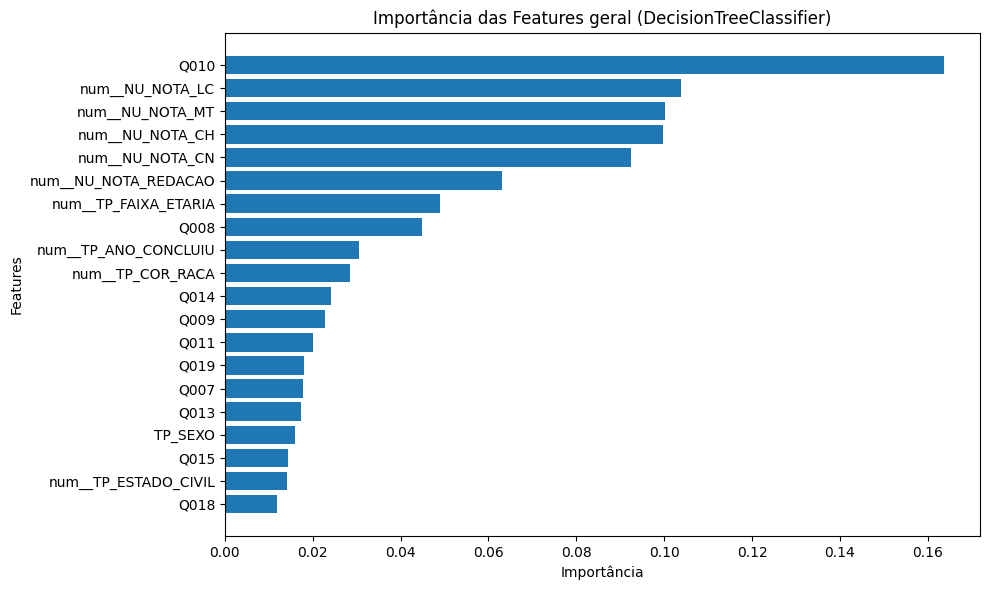

In [9]:
df_importancia = analisar_importancia_features_agregada(modelo, clf, "geral", 20)


Importância das features (sem agregação):
cat__Q010_A: 0.1571
num__NU_NOTA_LC: 0.1039
num__NU_NOTA_MT: 0.1003
num__NU_NOTA_CH: 0.0997
num__NU_NOTA_CN: 0.0924
num__NU_NOTA_REDACAO: 0.0631
num__TP_FAIXA_ETARIA: 0.0489
cat__Q008_B: 0.0366
num__TP_ANO_CONCLUIU: 0.0305
num__TP_COR_RACA: 0.0284
cat__Q014_A: 0.0211
num__TP_ESTADO_CIVIL: 0.0142
cat__Q007_A: 0.0136
num__TP_ESCOLA: 0.0091
cat__Q018_B: 0.0086


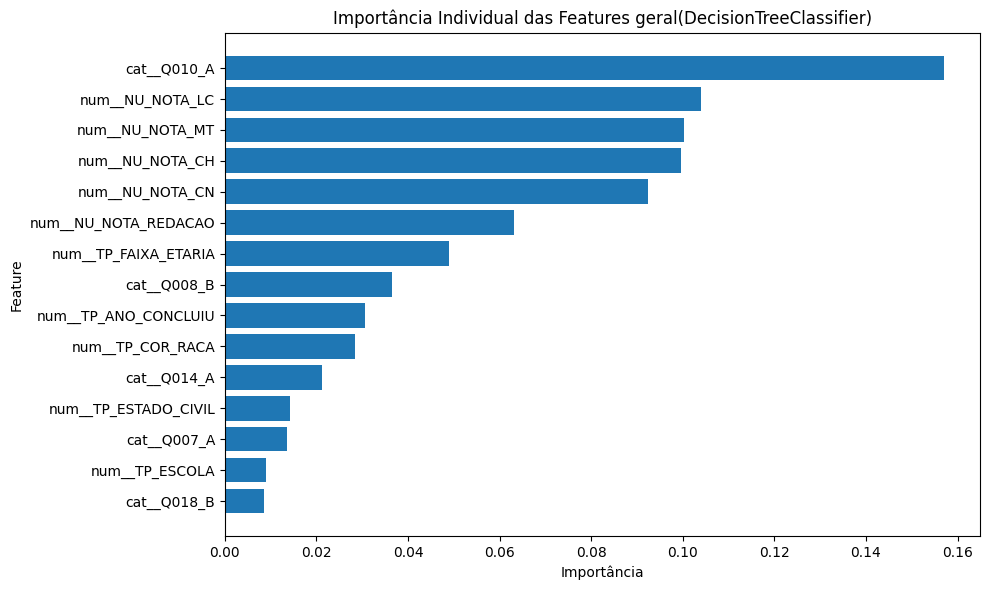

In [10]:
df_importancias_individuais = analisar_importancia_features(modelo, clf, "geral", top_n=15)



Resumo estatístico completo por classe social geral:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 501.009225 519.979717      62.699234 3931.193921 463.680000 519.979717           0.0        826.30     826.30 12.514587
   De 2 a 3 salários mínimos 526.035781 519.979717      66.035197 4360.647299 492.322383 558.760000           0.0        816.18     816.18 12.553366
   De 3 a 6 salários mínimos 553.466943 537.129533      75.024345 5628.652285 517.320000 603.020000           0.0        845.00     845.00 13.555343
  De 6 a 10 salários mínimos 590.439163 589.680000      79.938222 6390.119278 519.979717 650.420000           0.0        850.82     850.82 13.538774
 De 10 a 15 salários mínimos 608.304717 612.600000      80.769178 6523.660042 534.930000 670.020000           0.0        842.70     842.70 13.277750
Acima de 15 salários mínimos 616.566036 623.880000  

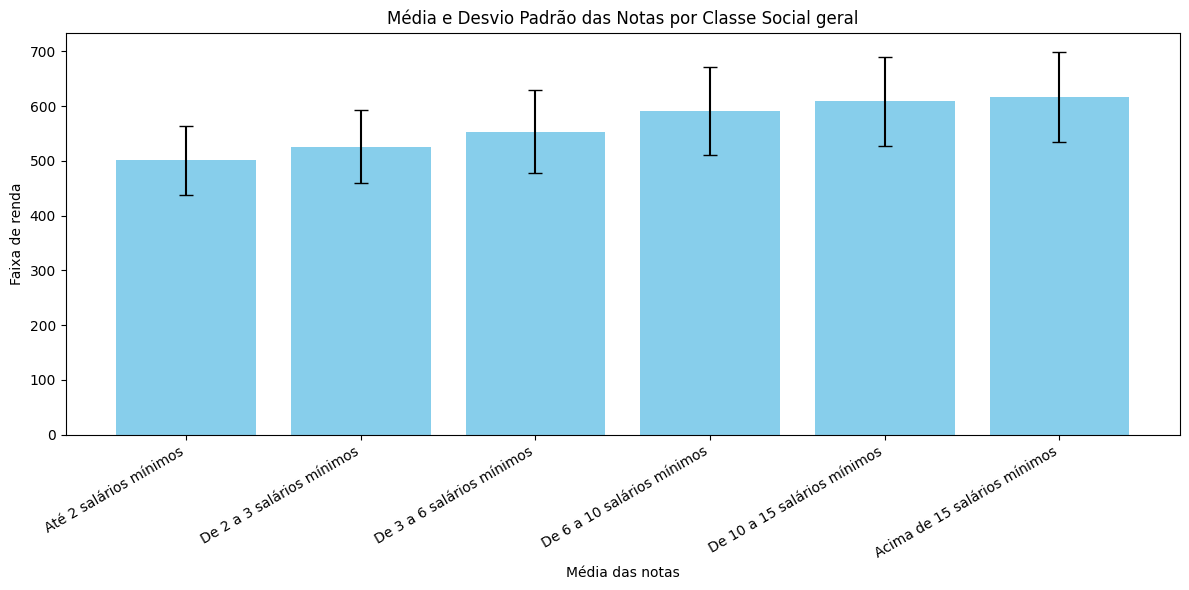

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,501.009225,519.979717,62.699234,3931.193921,463.680000,519.979717,0.0,826.30,826.30,12.514587,1
3,De 2 a 3 salários mínimos,526.035781,519.979717,66.035197,4360.647299,492.322383,558.760000,0.0,816.18,816.18,12.553366,2
4,De 3 a 6 salários mínimos,553.466943,537.129533,75.024345,5628.652285,517.320000,603.020000,0.0,845.00,845.00,13.555343,3
5,De 6 a 10 salários mínimos,590.439163,589.680000,79.938222,6390.119278,519.979717,650.420000,0.0,850.82,850.82,13.538774,4
2,De 10 a 15 salários mínimos,608.304717,612.600000,80.769178,6523.660042,534.930000,670.020000,0.0,842.70,842.70,13.277750,5
0,Acima de 15 salários mínimos,616.566036,623.880000,82.143034,6747.478027,541.749533,679.980000,0.0,837.48,837.48,13.322666,6


In [11]:
analisar_desempenho_por_classe(dataset_sem_nulos, "geral")

In [12]:
# Filtrar apenas homens
dataset_homem = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "M"]

# Filtrar apenas mulheres
dataset_mulher = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "F"]

In [13]:
modelo_homem, clf_homem = treinar_modelo(dataset_homem)

Acurácia: 0.9710513319934807

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       0.99      1.00      0.99     30053
      Até 2 salários mínimos       0.96      1.00      0.98   1239805
 De 10 a 15 salários mínimos       0.99      0.98      0.99     46414
   De 2 a 3 salários mínimos       0.98      0.88      0.93    207039
   De 3 a 6 salários mínimos       0.98      0.94      0.96    440525
  De 6 a 10 salários mínimos       1.00      0.96      0.98     99575

                    accuracy                           0.97   2063411
                   macro avg       0.98      0.96      0.97   2063411
                weighted avg       0.97      0.97      0.97   2063411


Matriz de confusão:
 [[  29916      75       8       3      43       8]
 [     44 1234976       5     847    3898      35]
 [     93     338   45706      14     235      28]
 [     23   22042      50  182560    2336      28]
 [     85   

Importância das features (agregada):
Feature Q010: 0.1565
Feature num__NU_NOTA_MT: 0.1018
Feature num__NU_NOTA_CH: 0.1001
Feature num__NU_NOTA_LC: 0.0978
Feature num__NU_NOTA_CN: 0.0930
Feature num__NU_NOTA_REDACAO: 0.0646
Feature num__TP_FAIXA_ETARIA: 0.0537
Feature Q008: 0.0417
Feature num__TP_ANO_CONCLUIU: 0.0343
Feature num__TP_COR_RACA: 0.0314
Feature Q009: 0.0242
Feature Q011: 0.0223
Feature Q014: 0.0215
Feature Q019: 0.0206
Feature Q013: 0.0196
Feature Q007: 0.0193
Feature Q015: 0.0155
Feature num__TP_ESTADO_CIVIL: 0.0153
Feature Q018: 0.0152
Feature Q016: 0.0118


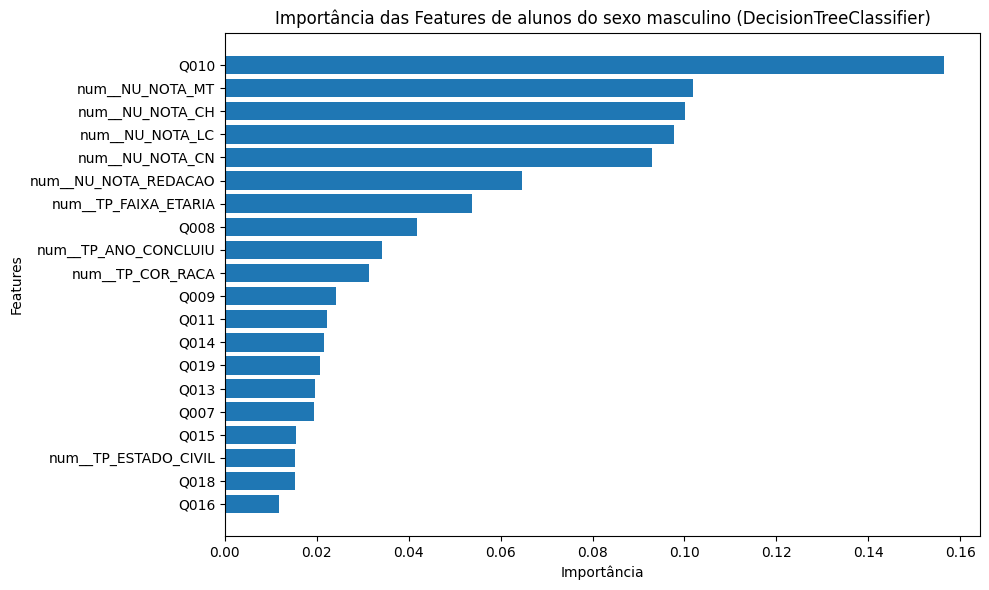

In [14]:
df_importancia_homem = analisar_importancia_features_agregada(modelo_homem, clf_homem, "de alunos do sexo masculino", 20)

Importância das features (sem agregação):
cat__Q010_A: 0.1493
num__NU_NOTA_MT: 0.1018
num__NU_NOTA_CH: 0.1001
num__NU_NOTA_LC: 0.0978
num__NU_NOTA_CN: 0.0930
num__NU_NOTA_REDACAO: 0.0646
num__TP_FAIXA_ETARIA: 0.0537
num__TP_ANO_CONCLUIU: 0.0343
cat__Q008_B: 0.0325
num__TP_COR_RACA: 0.0314
cat__Q014_A: 0.0181
num__TP_ESTADO_CIVIL: 0.0153
cat__Q007_A: 0.0147
cat__Q018_A: 0.0138
num__TP_ESCOLA: 0.0099


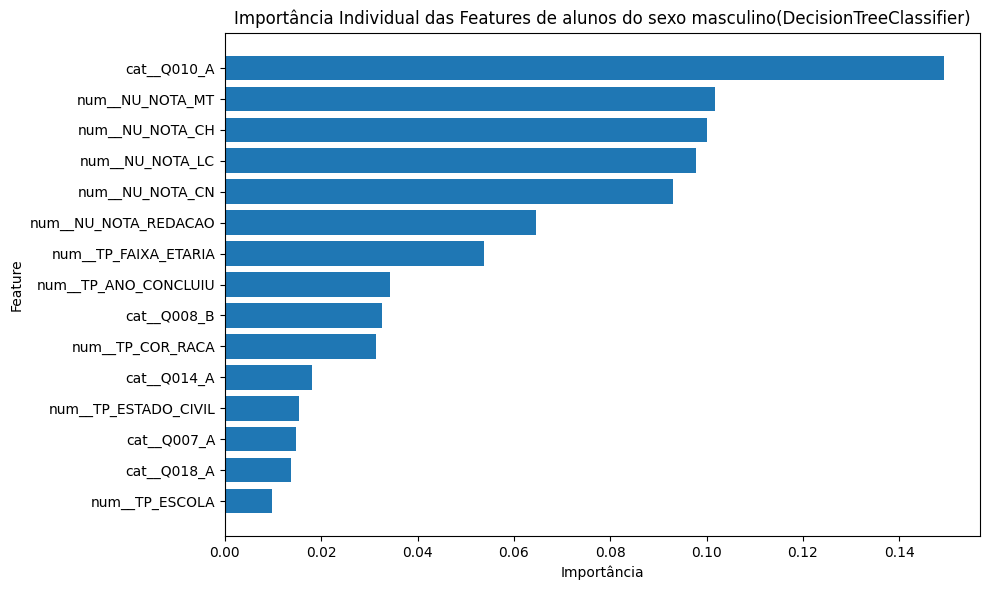

In [15]:
df_importancias_individuais_homem = analisar_importancia_features(modelo_homem, clf_homem, "de alunos do sexo masculino", top_n=15)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)



Resumo estatístico completo por classe social de alunos do sexo masculino:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 505.019603 519.979717      65.988072 4354.425710 467.120000 529.200000          0.00        826.30     826.30 13.066438
   De 2 a 3 salários mínimos 527.647664 519.979717      67.564467 4564.957263 494.880000 563.104767          0.00        816.02     816.02 12.804845
   De 3 a 6 salários mínimos 552.530525 535.860000      75.601257 5715.550049 518.940000 602.380000          0.00        845.00     845.00 13.682729
  De 6 a 10 salários mínimos 587.435993 586.120000      81.349139 6617.682403 519.979717 647.620000         73.74        850.82     777.08 13.848171
 De 10 a 15 salários mínimos 606.707684 610.990000      82.666712 6833.785305 525.925000 669.755000          0.00        832.82     832.82 13.625460
Acima de 15 salários mínimos 6

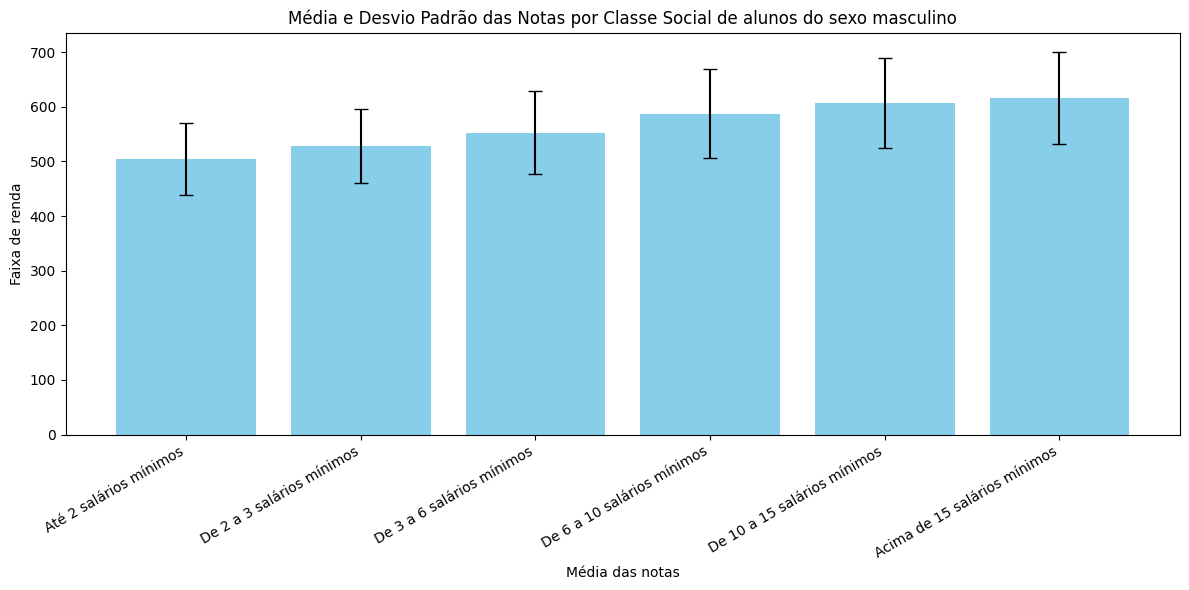

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,505.019603,519.979717,65.988072,4354.425710,467.120000,529.200000,0.00,826.30,826.30,13.066438,1
3,De 2 a 3 salários mínimos,527.647664,519.979717,67.564467,4564.957263,494.880000,563.104767,0.00,816.02,816.02,12.804845,2
4,De 3 a 6 salários mínimos,552.530525,535.860000,75.601257,5715.550049,518.940000,602.380000,0.00,845.00,845.00,13.682729,3
5,De 6 a 10 salários mínimos,587.435993,586.120000,81.349139,6617.682403,519.979717,647.620000,73.74,850.82,777.08,13.848171,4
2,De 10 a 15 salários mínimos,606.707684,610.990000,82.666712,6833.785305,525.925000,669.755000,0.00,832.82,832.82,13.625460,5
0,Acima de 15 salários mínimos,615.844835,623.240000,84.522825,7144.108002,533.729533,681.040000,0.00,837.48,837.48,13.724695,6


In [16]:
analisar_desempenho_por_classe(dataset_homem, "de alunos do sexo masculino")

In [17]:
modelo_mulher, clf_mulher = treinar_modelo(dataset_mulher)

Acurácia: 0.9748753199461698

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       0.99      1.00      0.99     27096
      Até 2 salários mínimos       0.97      1.00      0.98   2076545
 De 10 a 15 salários mínimos       0.99      0.99      0.99     47041
   De 2 a 3 salários mínimos       0.99      0.87      0.92    268515
   De 3 a 6 salários mínimos       0.98      0.94      0.96    504980
  De 6 a 10 salários mínimos       1.00      0.97      0.98    107583

                    accuracy                           0.97   3031760
                   macro avg       0.99      0.96      0.97   3031760
                weighted avg       0.98      0.97      0.97   3031760


Matriz de confusão:
 [[  26985      46      19       0      36      10]
 [     35 2071706       6    1037    3711      50]
 [     86     326   46367       8     220      34]
 [     12   32951      58  233317    2140      37]
 [     98   

Importância das features (agregada):
Feature Q010: 0.1667
Feature num__NU_NOTA_LC: 0.1152
Feature num__NU_NOTA_CH: 0.0996
Feature num__NU_NOTA_MT: 0.0991
Feature num__NU_NOTA_CN: 0.0954
Feature num__NU_NOTA_REDACAO: 0.0625
Feature num__TP_FAIXA_ETARIA: 0.0476
Feature Q008: 0.0465
Feature num__TP_ANO_CONCLUIU: 0.0303
Feature num__TP_COR_RACA: 0.0276
Feature Q014: 0.0237
Feature Q009: 0.0232
Feature Q011: 0.0202
Feature Q019: 0.0196
Feature Q013: 0.0173


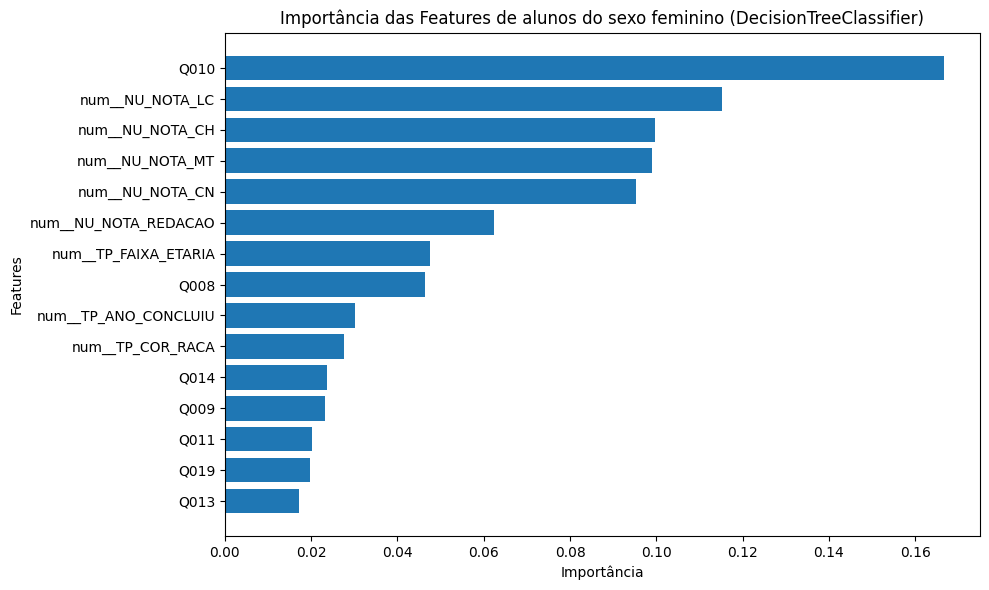

In [18]:
df_importancias_mulher = analisar_importancia_features_agregada(modelo_mulher,clf_mulher, "de alunos do sexo feminino", top_n=15)

Importância das features (sem agregação):
cat__Q010_A: 0.1597
num__NU_NOTA_LC: 0.1152
num__NU_NOTA_CH: 0.0996
num__NU_NOTA_MT: 0.0991
num__NU_NOTA_CN: 0.0954
num__NU_NOTA_REDACAO: 0.0625
num__TP_FAIXA_ETARIA: 0.0476
cat__Q008_B: 0.0387
num__TP_ANO_CONCLUIU: 0.0303
num__TP_COR_RACA: 0.0276
cat__Q014_A: 0.0210
num__TP_ESTADO_CIVIL: 0.0138
cat__Q007_A: 0.0129
num__TP_ESCOLA: 0.0099
num__TP_ST_CONCLUSAO: 0.0092


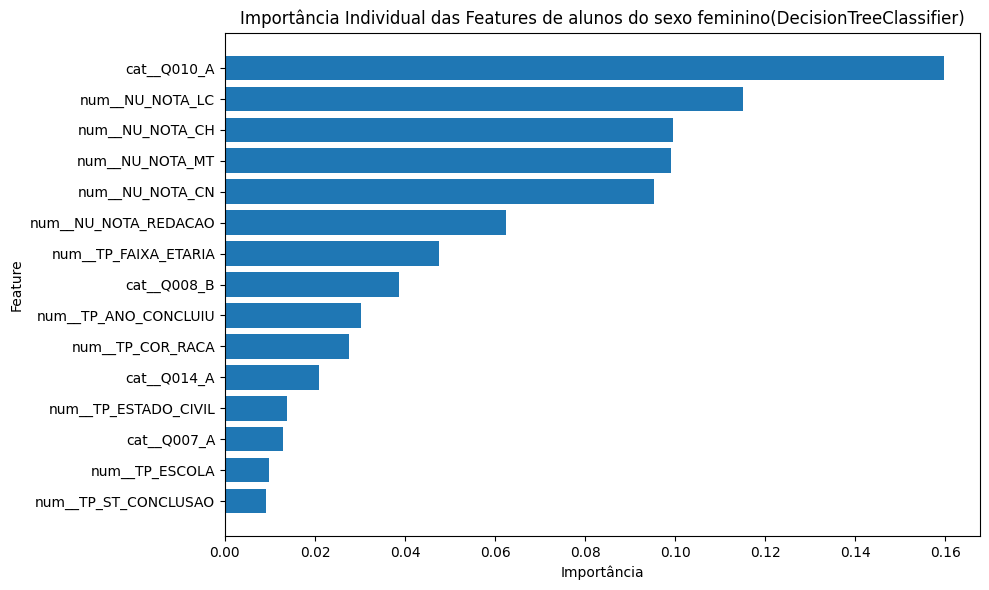

In [19]:
df_importancias_individuais_mulher = analisar_importancia_features(modelo_mulher, clf_mulher, "de alunos do sexo feminino", top_n=15)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)



Resumo estatístico completo por classe social de alunos do sexo feminino:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 498.614822 515.640000      60.524119 3663.168943 462.000000 519.979717      0.000000        816.10 816.100000 12.138452
   De 2 a 3 salários mínimos 524.792936 519.979717      64.804183 4199.582129 490.620000 555.260000    164.080000        816.18 652.100000 12.348524
   De 3 a 6 salários mínimos 554.283837 538.120000      74.507885 5551.424934 516.180000 603.640000      0.000000        835.90 835.900000 13.442190
  De 6 a 10 salários mínimos 593.218792 592.760000      78.507836 6163.480316 519.979717 652.860000      0.000000        838.56 838.560000 13.234213
 De 10 a 15 salários mínimos 609.880462 614.060000      78.821365 6212.807549 541.560000 670.380000    184.900000        842.70 657.800000 12.924068
Acima de 15 salários mínimos 61

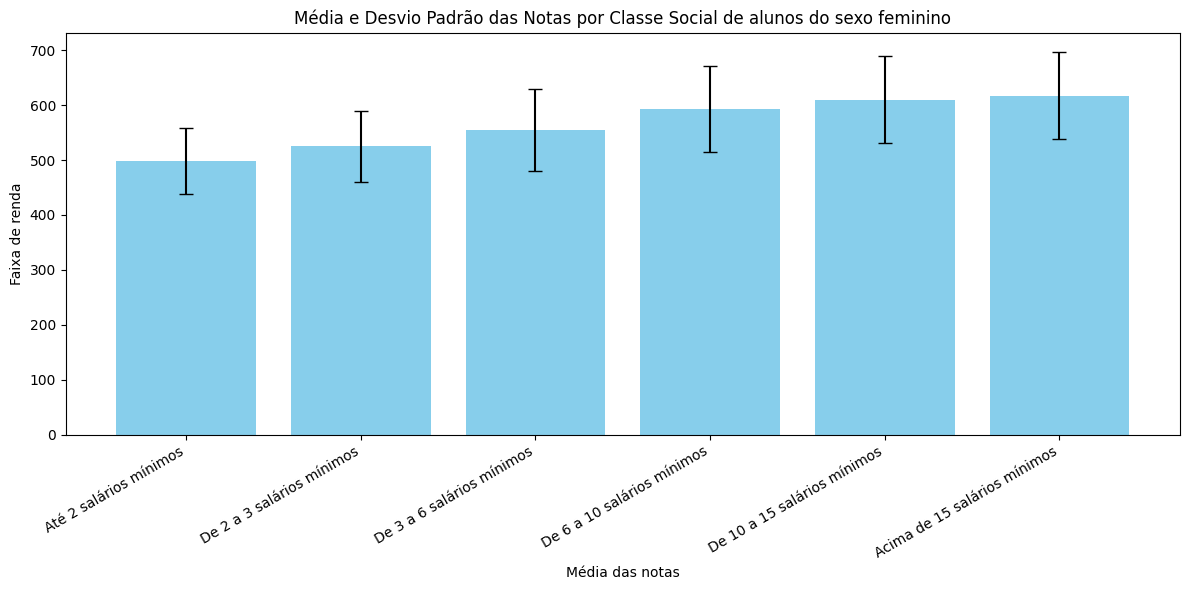

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,498.614822,515.640000,60.524119,3663.168943,462.000000,519.979717,0.000000,816.10,816.100000,12.138452,1
3,De 2 a 3 salários mínimos,524.792936,519.979717,64.804183,4199.582129,490.620000,555.260000,164.080000,816.18,652.100000,12.348524,2
4,De 3 a 6 salários mínimos,554.283837,538.120000,74.507885,5551.424934,516.180000,603.640000,0.000000,835.90,835.900000,13.442190,3
5,De 6 a 10 salários mínimos,593.218792,592.760000,78.507836,6163.480316,519.979717,652.860000,0.000000,838.56,838.560000,13.234213,4
2,De 10 a 15 salários mínimos,609.880462,614.060000,78.821365,6212.807549,541.560000,670.380000,184.900000,842.70,657.800000,12.924068,5
0,Acima de 15 salários mínimos,617.365942,624.740000,79.414068,6306.594269,548.627150,678.860000,200.189533,825.30,625.110467,12.863370,6


In [20]:
analisar_desempenho_por_classe(dataset_mulher, "de alunos do sexo feminino")

In [21]:
# Filtrar apenas escolas urbanas
dataset_urbano = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 1]

# Filtrar apenas escolas rurais
dataset_rural = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 2]

In [22]:
modelo_urbano, clf_urbano = treinar_modelo(dataset_urbano)

Acurácia: 0.9731304032942657

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       0.99      1.00      0.99     57090
      Até 2 salários mínimos       0.97      1.00      0.98   3282537
 De 10 a 15 salários mínimos       0.99      0.99      0.99     93335
   De 2 a 3 salários mínimos       0.98      0.87      0.93    472766
   De 3 a 6 salários mínimos       0.98      0.94      0.96    941301
  De 6 a 10 salários mínimos       1.00      0.96      0.98    206601

                    accuracy                           0.97   5053630
                   macro avg       0.98      0.96      0.97   5053630
                weighted avg       0.97      0.97      0.97   5053630


Matriz de confusão:
 [[  56842     121      27       3      79      18]
 [     79 3272869      11    1884    7609      85]
 [    179     664   91953      22     455      62]
 [     35   54926     108  413156    4476      65]
 [    183   

Importância das features (agregada):
Feature Q010: 0.1637
Feature num__NU_NOTA_MT: 0.1033
Feature num__NU_NOTA_CH: 0.1002
Feature num__NU_NOTA_LC: 0.0997
Feature num__NU_NOTA_CN: 0.0928
Feature num__NU_NOTA_REDACAO: 0.0628
Feature num__TP_FAIXA_ETARIA: 0.0493
Feature Q008: 0.0448
Feature num__TP_ANO_CONCLUIU: 0.0308
Feature num__TP_COR_RACA: 0.0285
Feature Q009: 0.0227
Feature Q014: 0.0212
Feature Q011: 0.0201
Feature Q019: 0.0180
Feature Q007: 0.0179
Feature Q013: 0.0172
Feature TP_SEXO: 0.0160
Feature Q018: 0.0154
Feature Q015: 0.0144
Feature num__TP_ESTADO_CIVIL: 0.0143


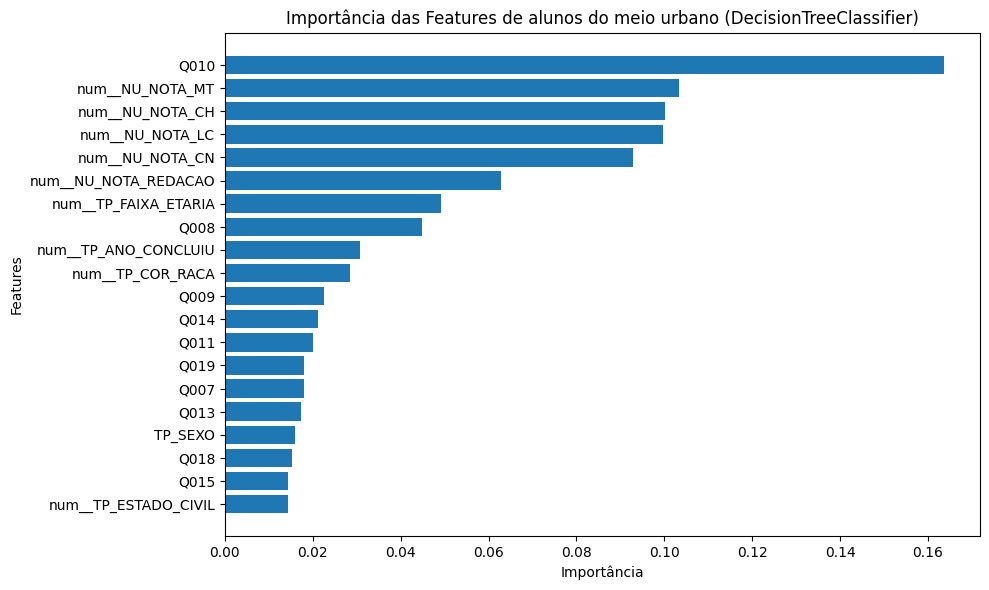

In [23]:
df_importancia_urbano = analisar_importancia_features_agregada(modelo_urbano, clf_urbano, "de alunos do meio urbano", 20)

Importância das features (sem agregação):
cat__Q010_A: 0.1570
num__NU_NOTA_MT: 0.1033
num__NU_NOTA_CH: 0.1002
num__NU_NOTA_LC: 0.0997
num__NU_NOTA_CN: 0.0928
num__NU_NOTA_REDACAO: 0.0628
num__TP_FAIXA_ETARIA: 0.0493
cat__Q008_B: 0.0365
num__TP_ANO_CONCLUIU: 0.0308
num__TP_COR_RACA: 0.0285
cat__Q014_A: 0.0182
num__TP_ESTADO_CIVIL: 0.0143
cat__Q007_A: 0.0136
cat__Q018_A: 0.0131
num__TP_ESCOLA: 0.0092


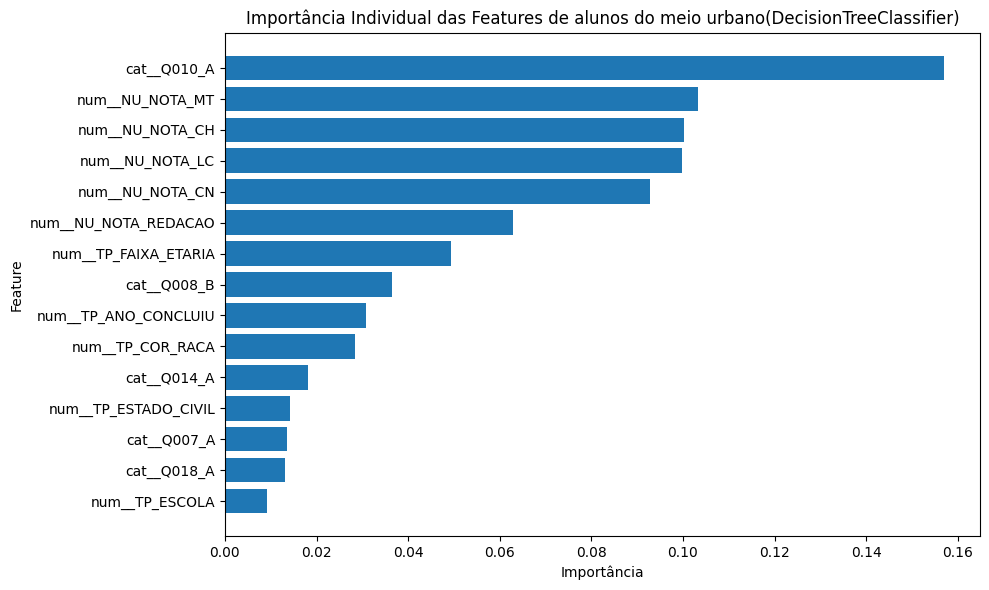

In [24]:
df_importancias_individuais_urbano = analisar_importancia_features(modelo_urbano, clf_urbano, "de alunos do meio urbano", top_n=15)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)



Resumo estatístico completo por classe social de alunos do meio urbano:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 501.164145 519.979717      62.613878 3920.497761 463.940000 519.979717           0.0        826.30     826.30 12.493687
   De 2 a 3 salários mínimos 526.046369 519.979717      66.000336 4356.044359 492.420000 558.680000           0.0        816.18     816.18 12.546486
   De 3 a 6 salários mínimos 553.487039 537.080000      75.022691 5628.404193 517.400000 603.020000           0.0        845.00     845.00 13.554552
  De 6 a 10 salários mínimos 590.482587 589.720000      79.932246 6389.163967 519.979717 650.480000           0.0        850.82     850.82 13.536766
 De 10 a 15 salários mínimos 608.340961 612.680000      80.772348 6524.172278 534.940000 670.070000           0.0        842.70     842.70 13.277480
Acima de 15 salários mínimos 616.

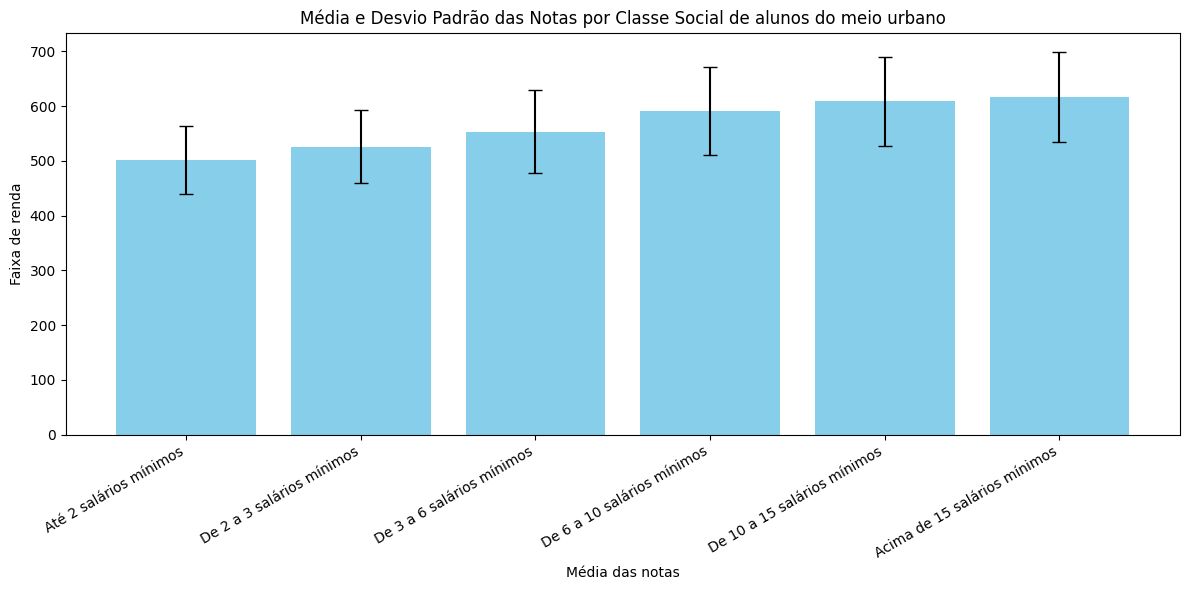

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,501.164145,519.979717,62.613878,3920.497761,463.940000,519.979717,0.0,826.30,826.30,12.493687,1
3,De 2 a 3 salários mínimos,526.046369,519.979717,66.000336,4356.044359,492.420000,558.680000,0.0,816.18,816.18,12.546486,2
4,De 3 a 6 salários mínimos,553.487039,537.080000,75.022691,5628.404193,517.400000,603.020000,0.0,845.00,845.00,13.554552,3
5,De 6 a 10 salários mínimos,590.482587,589.720000,79.932246,6389.163967,519.979717,650.480000,0.0,850.82,850.82,13.536766,4
2,De 10 a 15 salários mínimos,608.340961,612.680000,80.772348,6524.172278,534.940000,670.070000,0.0,842.70,842.70,13.277480,5
0,Acima de 15 salários mínimos,616.616620,623.920000,82.124220,6744.387590,541.825000,680.000000,0.0,837.48,837.48,13.318522,6


In [25]:
analisar_desempenho_por_classe(dataset_urbano, "de alunos do meio urbano")

In [26]:
# Filtrar apenas homens do meio urbano
dataset_urbano_homem = dataset_urbano[dataset_urbano['TP_SEXO'] == "M"]

# Filtrar apenas mulheres do meio urbano
dataset_urbano_mulher = dataset_urbano[dataset_urbano['TP_SEXO'] == "F"]

In [27]:
modelo_urbano_homem, clf_urbano_homem = treinar_modelo(dataset_urbano_homem)

Acurácia: 0.9708254154650329

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       0.99      1.00      0.99     30018
      Até 2 salários mínimos       0.96      1.00      0.98   1225827
 De 10 a 15 salários mínimos       0.99      0.98      0.99     46354
   De 2 a 3 salários mínimos       0.98      0.88      0.93    205683
   De 3 a 6 salários mínimos       0.98      0.94      0.96    438319
  De 6 a 10 salários mínimos       1.00      0.96      0.98     99278

                    accuracy                           0.97   2045479
                   macro avg       0.98      0.96      0.97   2045479
                weighted avg       0.97      0.97      0.97   2045479


Matriz de confusão:
 [[  29881      75       8       3      43       8]
 [     44 1220998       5     847    3898      35]
 [     93     338   45646      14     235      28]
 [     23   22009      50  181237    2336      28]
 [     85   

Importância das features (agregada):
Feature Q010: 0.1564
Feature num__NU_NOTA_MT: 0.1023
Feature num__NU_NOTA_CH: 0.1000
Feature num__NU_NOTA_LC: 0.0983
Feature num__NU_NOTA_CN: 0.0929
Feature num__NU_NOTA_REDACAO: 0.0649
Feature num__TP_FAIXA_ETARIA: 0.0537
Feature Q008: 0.0416
Feature num__TP_ANO_CONCLUIU: 0.0342
Feature num__TP_COR_RACA: 0.0314
Feature Q009: 0.0244
Feature Q011: 0.0224
Feature Q014: 0.0214
Feature Q019: 0.0207
Feature Q007: 0.0194
Feature Q013: 0.0192
Feature Q015: 0.0156
Feature num__TP_ESTADO_CIVIL: 0.0154
Feature Q018: 0.0151
Feature Q016: 0.0119


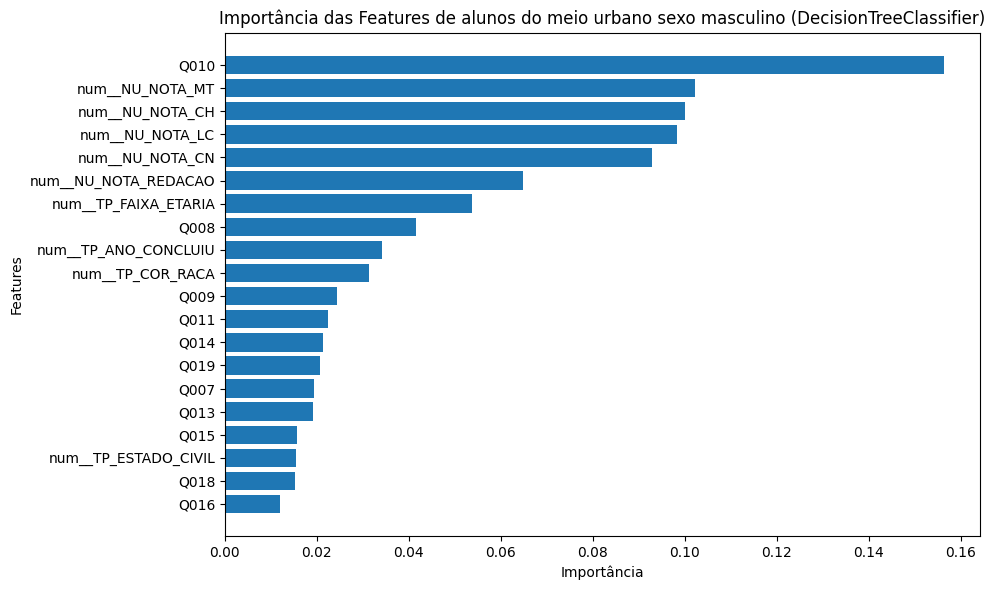

In [28]:
df_importancia_urbano_homem = analisar_importancia_features_agregada(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino", 20)

Importância das features (sem agregação):
cat__Q010_A: 0.1491
num__NU_NOTA_MT: 0.1023
num__NU_NOTA_CH: 0.1000
num__NU_NOTA_LC: 0.0983
num__NU_NOTA_CN: 0.0929
num__NU_NOTA_REDACAO: 0.0649
num__TP_FAIXA_ETARIA: 0.0537
num__TP_ANO_CONCLUIU: 0.0342
cat__Q008_B: 0.0324
num__TP_COR_RACA: 0.0314
cat__Q014_A: 0.0180
num__TP_ESTADO_CIVIL: 0.0154
cat__Q007_A: 0.0147
num__TP_ESCOLA: 0.0100
cat__Q018_A: 0.0098


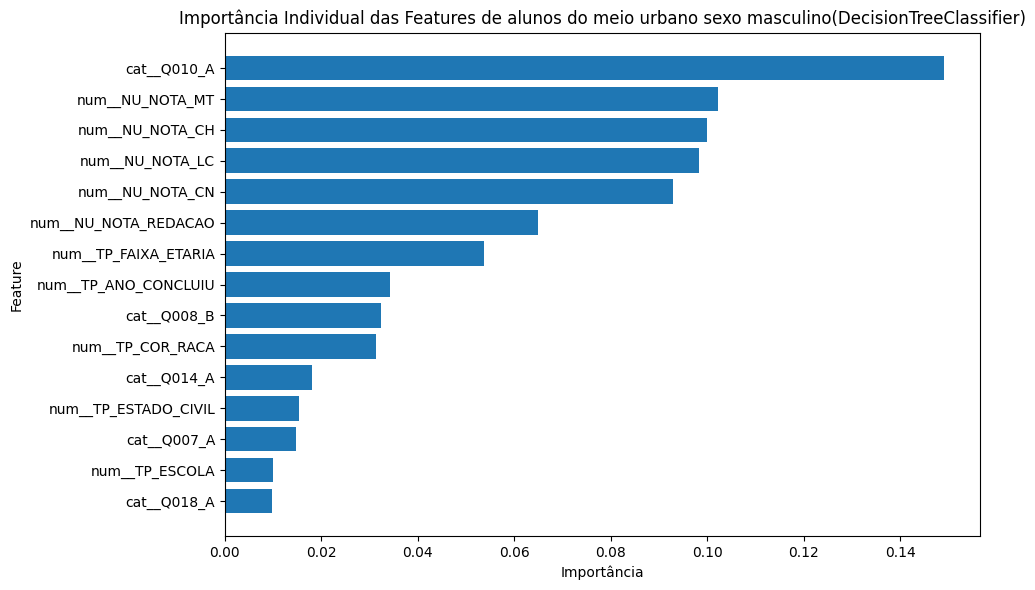

In [29]:
df_importancias_individuais_urbano_homem = analisar_importancia_features(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino", top_n=15)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)



Resumo estatístico completo por classe social de alunos do meio urbano sexo masculino:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 505.227483 519.979717      65.870642 4338.941420 467.460000 529.340000          0.00        826.30     826.30 13.037818
   De 2 a 3 salários mínimos 527.680729 519.979717      67.501146 4556.404744 495.040000 563.014767          0.00        816.02     816.02 12.792043
   De 3 a 6 salários mínimos 552.558060 535.820000      75.588534 5713.626454 519.040000 602.380000          0.00        845.00     845.00 13.679745
  De 6 a 10 salários mínimos 587.480807 586.180000      81.357184 6618.991449 519.979717 647.700000         73.74        850.82     777.08 13.848484
 De 10 a 15 salários mínimos 606.732737 611.040000      82.667589 6833.930231 525.925000 669.760000          0.00        832.82     832.82 13.625042
Acima de 15 salári

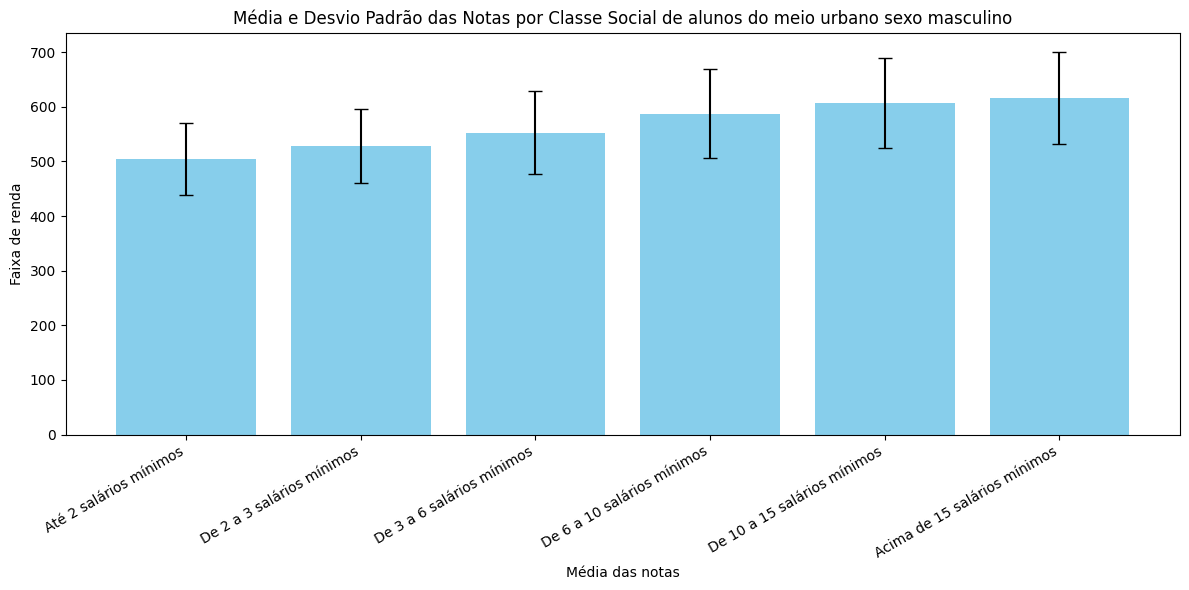

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,505.227483,519.979717,65.870642,4338.941420,467.460000,529.340000,0.00,826.30,826.30,13.037818,1
3,De 2 a 3 salários mínimos,527.680729,519.979717,67.501146,4556.404744,495.040000,563.014767,0.00,816.02,816.02,12.792043,2
4,De 3 a 6 salários mínimos,552.558060,535.820000,75.588534,5713.626454,519.040000,602.380000,0.00,845.00,845.00,13.679745,3
5,De 6 a 10 salários mínimos,587.480807,586.180000,81.357184,6618.991449,519.979717,647.700000,73.74,850.82,777.08,13.848484,4
2,De 10 a 15 salários mínimos,606.732737,611.040000,82.667589,6833.930231,525.925000,669.760000,0.00,832.82,832.82,13.625042,5
0,Acima de 15 salários mínimos,615.916920,623.330000,84.495085,7139.419470,533.835000,681.075000,0.00,837.48,837.48,13.718585,6


In [30]:
analisar_desempenho_por_classe(dataset_urbano_homem, "de alunos do meio urbano sexo masculino")

In [31]:
modelo_urbano_mulher, clf_urbano_mulher = treinar_modelo(dataset_urbano_mulher)

Acurácia: 0.9746977462235107

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       0.99      1.00      0.99     27072
      Até 2 salários mínimos       0.97      1.00      0.98   2056710
 De 10 a 15 salários mínimos       0.99      0.99      0.99     46981
   De 2 a 3 salários mínimos       0.99      0.87      0.92    267083
   De 3 a 6 salários mínimos       0.98      0.94      0.96    502982
  De 6 a 10 salários mínimos       1.00      0.97      0.98    107323

                    accuracy                           0.97   3008151
                   macro avg       0.99      0.96      0.97   3008151
                weighted avg       0.98      0.97      0.97   3008151


Matriz de confusão:
 [[  26961      46      19       0      36      10]
 [     35 2051871       6    1037    3711      50]
 [     86     326   46307       8     220      34]
 [     12   32917      58  231919    2140      37]
 [     98   

Importância das features (agregada):
Feature Q010: 0.1666
Feature num__NU_NOTA_LC: 0.1154
Feature num__NU_NOTA_CH: 0.1002
Feature num__NU_NOTA_MT: 0.0986
Feature num__NU_NOTA_CN: 0.0957
Feature num__NU_NOTA_REDACAO: 0.0623
Feature num__TP_FAIXA_ETARIA: 0.0475
Feature Q008: 0.0464
Feature num__TP_ANO_CONCLUIU: 0.0304
Feature num__TP_COR_RACA: 0.0283
Feature Q014: 0.0236
Feature Q009: 0.0232
Feature Q011: 0.0199
Feature Q019: 0.0196
Feature Q013: 0.0174
Feature Q007: 0.0172
Feature Q015: 0.0141
Feature num__TP_ESTADO_CIVIL: 0.0138
Feature Q018: 0.0119
Feature Q016: 0.0109


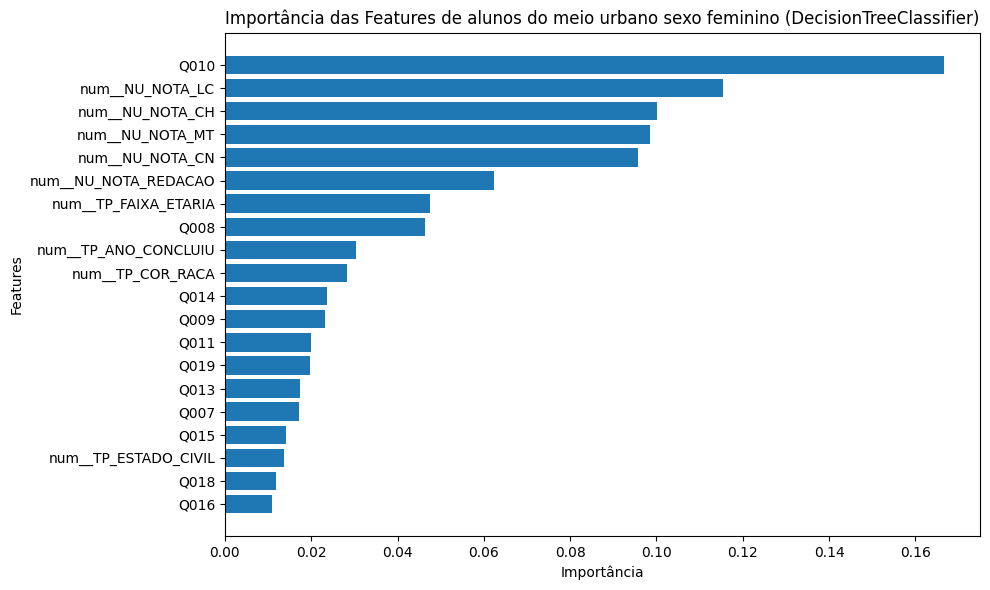

In [32]:
df_importancia_urbano_mulher = analisar_importancia_features_agregada(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino", 20)

Importância das features (sem agregação):
cat__Q010_A: 0.1597
num__NU_NOTA_LC: 0.1154
num__NU_NOTA_CH: 0.1002
num__NU_NOTA_MT: 0.0986
num__NU_NOTA_CN: 0.0957
num__NU_NOTA_REDACAO: 0.0623
num__TP_FAIXA_ETARIA: 0.0475
cat__Q008_B: 0.0386
num__TP_ANO_CONCLUIU: 0.0304
num__TP_COR_RACA: 0.0283
cat__Q014_A: 0.0209
num__TP_ESTADO_CIVIL: 0.0138
cat__Q007_A: 0.0130
num__TP_ESCOLA: 0.0099
cat__Q018_A: 0.0094


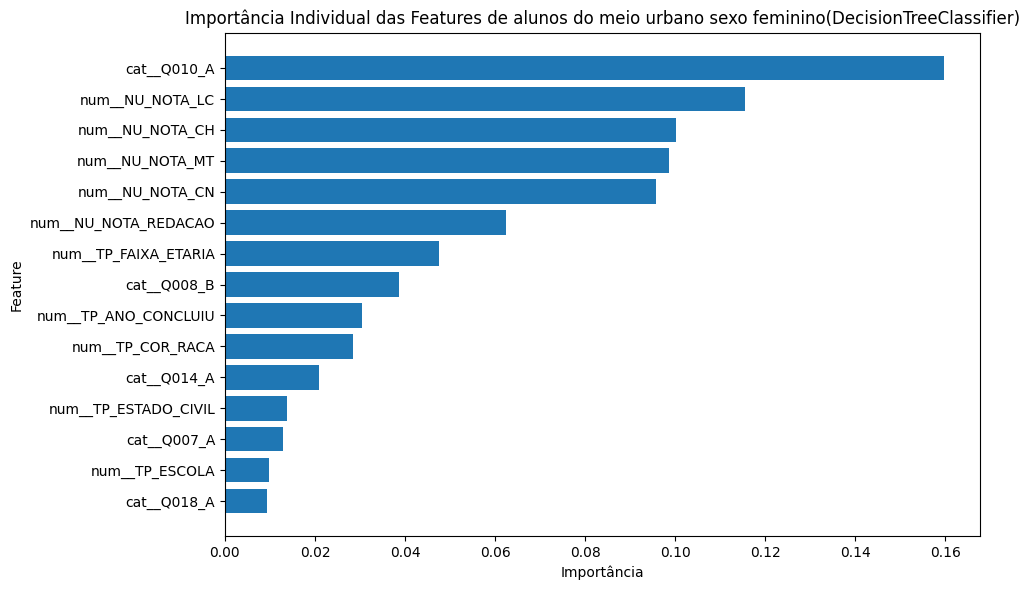

In [33]:
df_importancias_individuais_urbano_mulher = analisar_importancia_features(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino", top_n=15)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)



Resumo estatístico completo por classe social de alunos do meio urbano sexo feminino:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 498.742340 515.880000      60.459870 3655.395911 462.209533 519.979717      0.000000        816.10 816.100000 12.122466
   De 2 a 3 salários mínimos 524.787734 519.979717      64.792903 4198.120283 490.660000 555.180000    164.080000        816.18 652.100000 12.346497
   De 3 a 6 salários mínimos 554.296589 538.080000      74.516722 5552.741827 516.220000 603.640000      0.000000        835.90 835.900000 13.443475
  De 6 a 10 salários mínimos 593.259352 592.780000      78.489352 6160.578380 519.979717 652.880000      0.000000        838.56 838.560000 13.230192
 De 10 a 15 salários mínimos 609.927722 614.140000      78.826502 6213.617473 541.600000 670.420000    184.900000        842.70 657.800000 12.923909
Acima de 15 salário

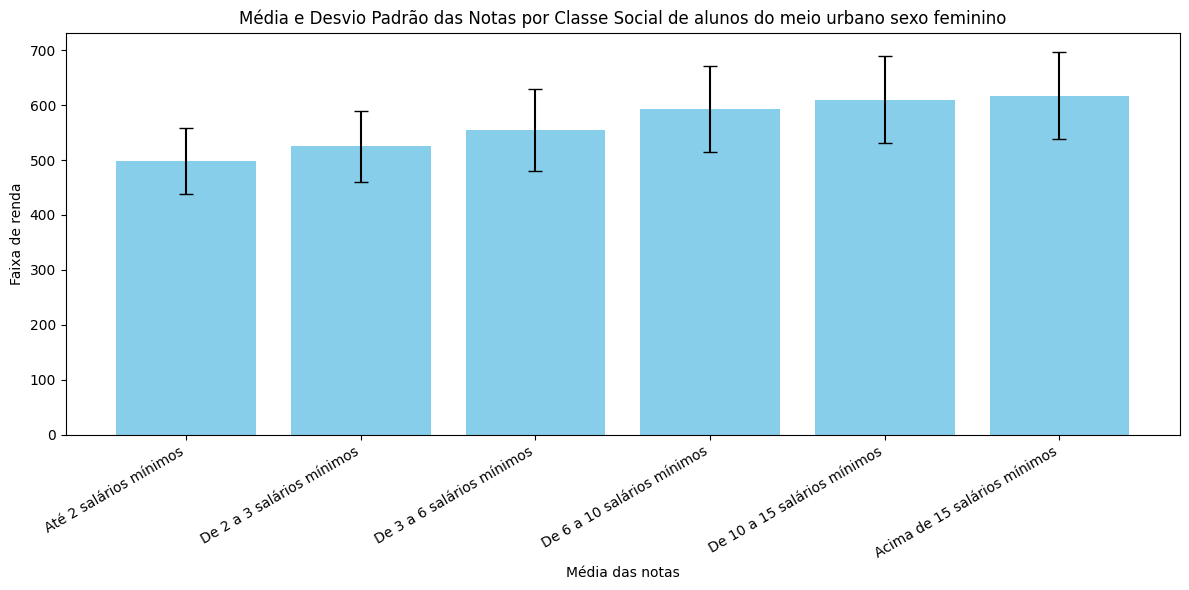

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,498.742340,515.880000,60.459870,3655.395911,462.209533,519.979717,0.000000,816.10,816.100000,12.122466,1
3,De 2 a 3 salários mínimos,524.787734,519.979717,64.792903,4198.120283,490.660000,555.180000,164.080000,816.18,652.100000,12.346497,2
4,De 3 a 6 salários mínimos,554.296589,538.080000,74.516722,5552.741827,516.220000,603.640000,0.000000,835.90,835.900000,13.443475,3
5,De 6 a 10 salários mínimos,593.259352,592.780000,78.489352,6160.578380,519.979717,652.880000,0.000000,838.56,838.560000,13.230192,4
2,De 10 a 15 salários mínimos,609.927722,614.140000,78.826502,6213.617473,541.600000,670.420000,184.900000,842.70,657.800000,12.923909,5
0,Acima de 15 salários mínimos,617.392462,624.740000,79.406994,6305.470697,548.652383,678.905000,200.189533,825.30,625.110467,12.861672,6


In [34]:
analisar_desempenho_por_classe(dataset_urbano_mulher, "de alunos do meio urbano sexo feminino")

In [35]:
modelo_rural, clf_rural = treinar_modelo(dataset_rural)

Acurácia: 0.9972075780554152

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        59
      Até 2 salários mínimos       1.00      1.00      1.00     33813
 De 10 a 15 salários mínimos       1.00      1.00      1.00       120
   De 2 a 3 salários mínimos       1.00      0.98      0.99      2788
   De 3 a 6 salários mínimos       1.00      0.99      0.99      4204
  De 6 a 10 salários mínimos       1.00      1.00      1.00       557

                    accuracy                           1.00     41541
                   macro avg       1.00      0.99      1.00     41541
                weighted avg       1.00      1.00      1.00     41541


Matriz de confusão:
 [[   59     0     0     0     0     0]
 [    0 33813     0     0     0     0]
 [    0     0   120     0     0     0]
 [    0    67     0  2721     0     0]
 [    0    45     0     3  4156     0]
 [    0     1     0  

Importância das features (agregada):
Feature Q010: 0.1562
Feature num__NU_NOTA_LC: 0.1125
Feature num__NU_NOTA_MT: 0.1083
Feature num__NU_NOTA_CN: 0.1023
Feature num__NU_NOTA_CH: 0.1004
Feature num__NU_NOTA_REDACAO: 0.0673
Feature Q008: 0.0488
Feature Q011: 0.0335
Feature Q009: 0.0325
Feature num__TP_FAIXA_ETARIA: 0.0303
Feature num__TP_COR_RACA: 0.0290
Feature Q019: 0.0276
Feature Q014: 0.0261
Feature Q013: 0.0251
Feature TP_SEXO: 0.0184
Feature Q015: 0.0145
Feature Q016: 0.0138
Feature Q018: 0.0127
Feature Q007: 0.0116
Feature Q012: 0.0097


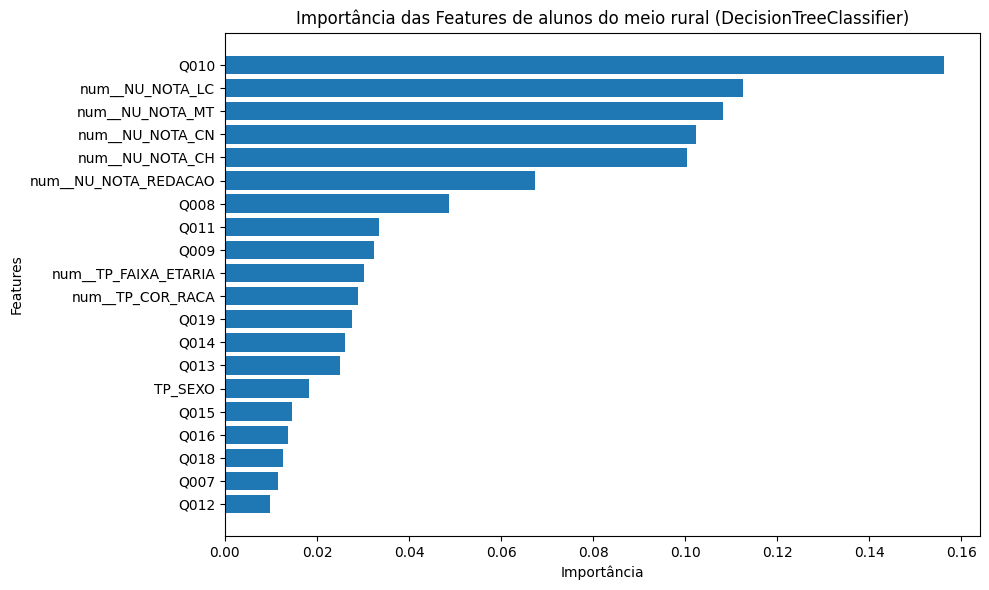

In [36]:
df_importancia_rural = analisar_importancia_features_agregada(modelo_rural,clf_rural, "de alunos do meio rural", top_n=20)

Importância das features (sem agregação):
cat__Q010_A: 0.1451
num__NU_NOTA_LC: 0.1125
num__NU_NOTA_MT: 0.1083
num__NU_NOTA_CN: 0.1023
num__NU_NOTA_CH: 0.1004
num__NU_NOTA_REDACAO: 0.0673
cat__Q008_B: 0.0378
num__TP_FAIXA_ETARIA: 0.0303
num__TP_COR_RACA: 0.0290
cat__Q014_A: 0.0212
cat__Q011_B: 0.0137
cat__Q011_A: 0.0119
cat__Q009_D: 0.0118
cat__Q013_B: 0.0111
cat__Q009_C: 0.0100


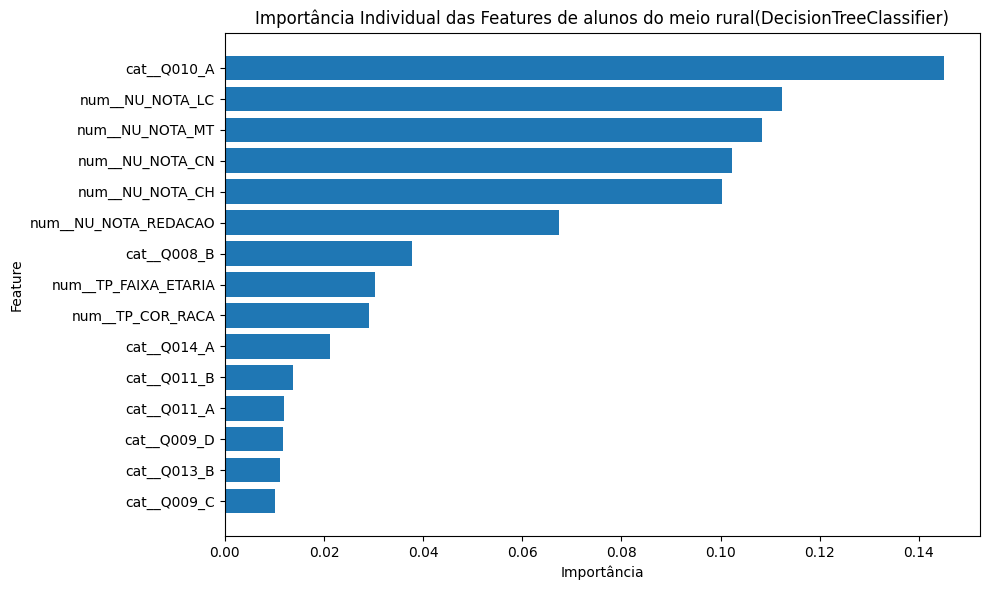

In [37]:
df_importancias_individuais_rural = analisar_importancia_features(modelo_rural, clf_rural, "de alunos do meio rural", top_n=15)


Resumo estatístico completo por classe social de alunos do meio rural:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 485.969789 494.520000      68.856324 4741.193300 440.500000 519.979717    154.320000        769.96 615.640000 14.168849
   De 2 a 3 salários mínimos 524.240422 519.979717      71.692227 5139.775377 477.735000 568.685000    200.189533        734.38 534.190467 13.675448
   De 3 a 6 salários mínimos 548.967313 544.750000      75.267603 5665.212087 502.340000 603.360000    162.800000        746.26 583.460000 13.710762
  De 6 a 10 salários mínimos 574.332565 576.840000      80.597764 6495.999588 519.979717 633.100000    200.189533        756.56 556.370467 14.033292
 De 10 a 15 salários mínimos 580.114317 586.640000      73.309733 5374.316985 526.845000 617.520000    368.400000        766.68 398.280000 12.637118
Acima de 15 salários mínimos 567.6

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)


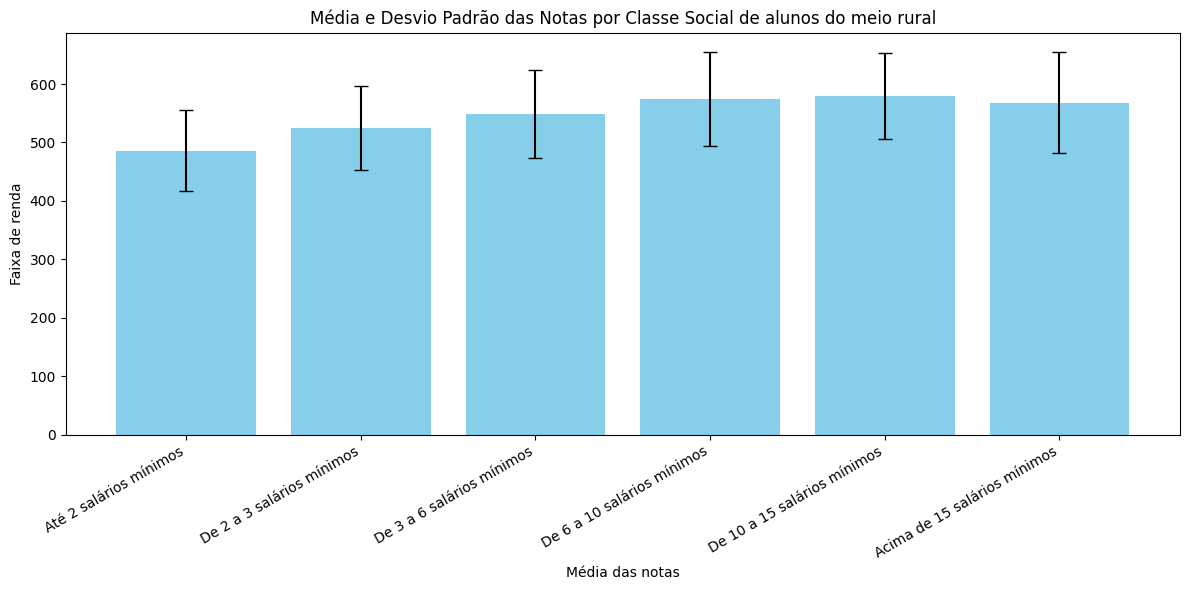

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,485.969789,494.520000,68.856324,4741.193300,440.500000,519.979717,154.320000,769.96,615.640000,14.168849,1
3,De 2 a 3 salários mínimos,524.240422,519.979717,71.692227,5139.775377,477.735000,568.685000,200.189533,734.38,534.190467,13.675448,2
4,De 3 a 6 salários mínimos,548.967313,544.750000,75.267603,5665.212087,502.340000,603.360000,162.800000,746.26,583.460000,13.710762,3
5,De 6 a 10 salários mínimos,574.332565,576.840000,80.597764,6495.999588,519.979717,633.100000,200.189533,756.56,556.370467,14.033292,4
2,De 10 a 15 salários mínimos,580.114317,586.640000,73.309733,5374.316985,526.845000,617.520000,368.400000,766.68,398.280000,12.637118,5
0,Acima de 15 salários mínimos,567.620304,564.020000,86.407182,7466.201119,509.144767,643.320000,381.100000,751.66,370.560000,15.222708,6


In [38]:
analisar_desempenho_por_classe(dataset_rural, "de alunos do meio rural")

In [39]:
# Filtrar apenas homens do meio rural
dataset_rural_homem = dataset_rural[dataset_rural['TP_SEXO'] == "M"]

# Filtrar apenas mulheres do meio rural
dataset_rural_mulher = dataset_rural[dataset_rural['TP_SEXO'] == "F"]

In [40]:
modelo_rural_homem, clf_rural_homem = treinar_modelo(dataset_rural_homem)

Acurácia: 0.9968213250055766

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        35
      Até 2 salários mínimos       1.00      1.00      1.00     13978
 De 10 a 15 salários mínimos       1.00      1.00      1.00        60
   De 2 a 3 salários mínimos       1.00      0.98      0.99      1356
   De 3 a 6 salários mínimos       1.00      0.99      0.99      2206
  De 6 a 10 salários mínimos       1.00      1.00      1.00       297

                    accuracy                           1.00     17932
                   macro avg       1.00      0.99      1.00     17932
                weighted avg       1.00      1.00      1.00     17932


Matriz de confusão:
 [[   35     0     0     0     0     0]
 [    0 13978     0     0     0     0]
 [    0     0    60     0     0     0]
 [    0    33     0  1323     0     0]
 [    0    23     0     1  2182     0]
 [    0     0     0  

Importância das features (agregada):
Feature Q010: 0.1641
Feature num__NU_NOTA_MT: 0.1107
Feature num__NU_NOTA_LC: 0.1060
Feature num__NU_NOTA_CH: 0.1010
Feature num__NU_NOTA_CN: 0.0936
Feature num__NU_NOTA_REDACAO: 0.0639
Feature Q008: 0.0482
Feature Q009: 0.0362
Feature num__TP_FAIXA_ETARIA: 0.0358
Feature num__TP_COR_RACA: 0.0325
Feature Q011: 0.0305
Feature Q014: 0.0296
Feature Q013: 0.0289
Feature Q019: 0.0275
Feature Q015: 0.0169
Feature Q018: 0.0149
Feature Q007: 0.0148
Feature Q016: 0.0143
Feature Q012: 0.0107
Feature num__TP_ESTADO_CIVIL: 0.0086


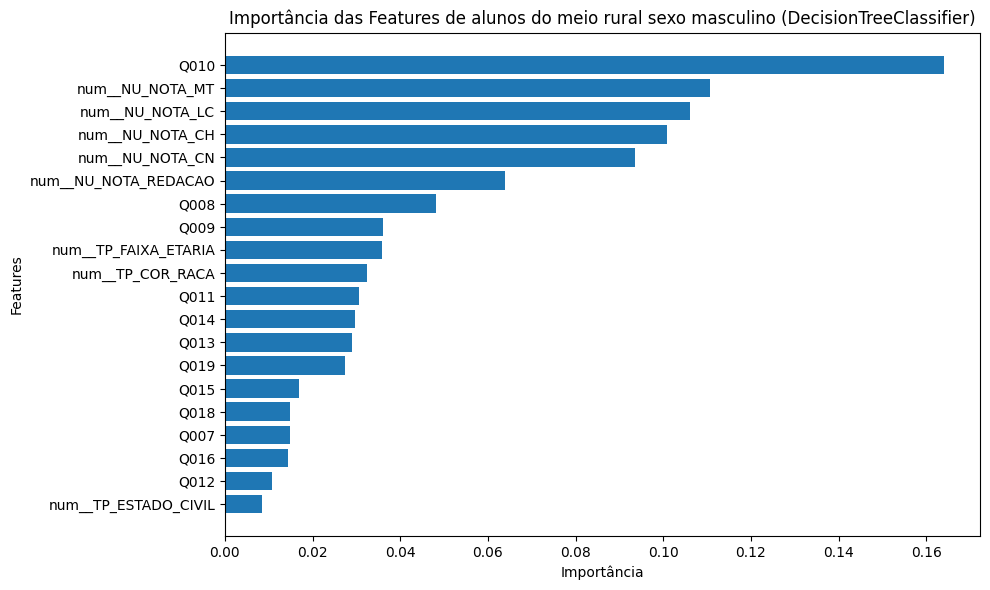

In [41]:
df_importancia_rural_homem = analisar_importancia_features_agregada(modelo_rural_homem,clf_rural_homem, "de alunos do meio rural sexo masculino", top_n=20)

Importância das features (sem agregação):
cat__Q010_A: 0.1526
num__NU_NOTA_MT: 0.1107
num__NU_NOTA_LC: 0.1060
num__NU_NOTA_CH: 0.1010
num__NU_NOTA_CN: 0.0936
num__NU_NOTA_REDACAO: 0.0639
cat__Q008_B: 0.0380
num__TP_FAIXA_ETARIA: 0.0358
num__TP_COR_RACA: 0.0325
cat__Q014_A: 0.0224
cat__Q009_D: 0.0144
cat__Q011_A: 0.0126
cat__Q013_B: 0.0119
cat__Q013_A: 0.0110
cat__Q009_C: 0.0109
cat__Q011_B: 0.0104
cat__Q019_C: 0.0098
cat__Q015_B: 0.0089
num__TP_ESTADO_CIVIL: 0.0086
cat__Q010_B: 0.0082


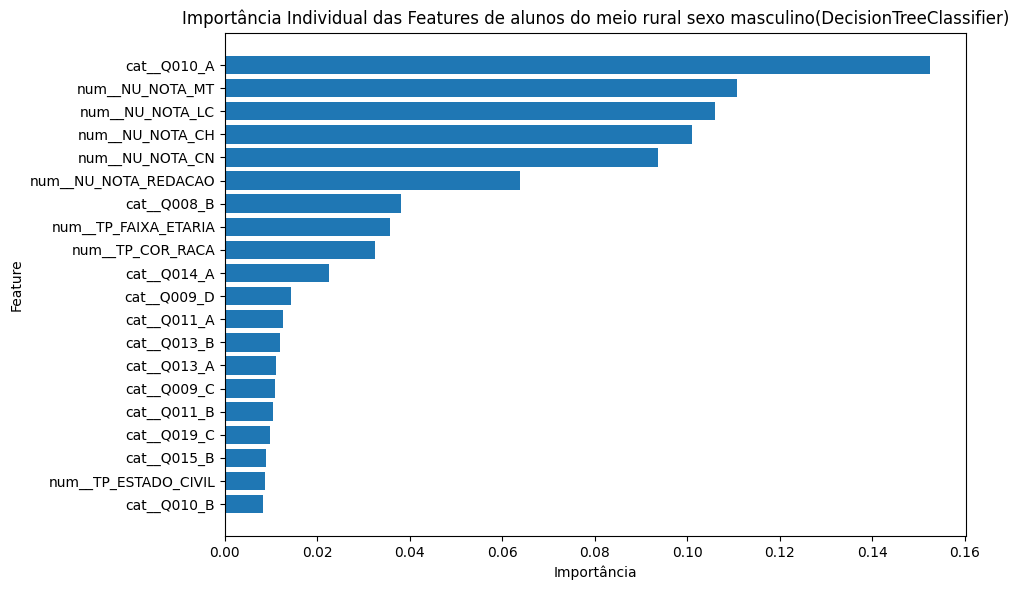

In [42]:
df_importancias_individuais_rural_homem = analisar_importancia_features(modelo_rural_homem, clf_rural_homem, "de alunos do meio rural sexo masculino", top_n=20)


Resumo estatístico completo por classe social de alunos do meio rural sexo masculino:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 486.789219 499.950000      73.325279 5376.596599 437.365000 519.979717    154.320000        739.94 585.620000 15.063045
   De 2 a 3 salários mínimos 522.632271 519.979717      76.427847 5841.215836 472.965000 572.630000    200.189533        734.38 534.190467 14.623637
   De 3 a 6 salários mínimos 547.059438 541.920000      77.912927 6070.424208 498.555000 603.375000    308.620000        746.26 437.640000 14.242132
  De 6 a 10 salários mínimos 572.456040 573.800000      77.299166 5975.160996 519.979717 627.700000    352.469533        756.56 404.090467 13.503075
 De 10 a 15 salários mínimos 587.352991 598.920000      80.338691 6454.305306 532.145000 642.335000    368.400000        766.68 398.280000 13.678093
Acima de 15 salário

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)


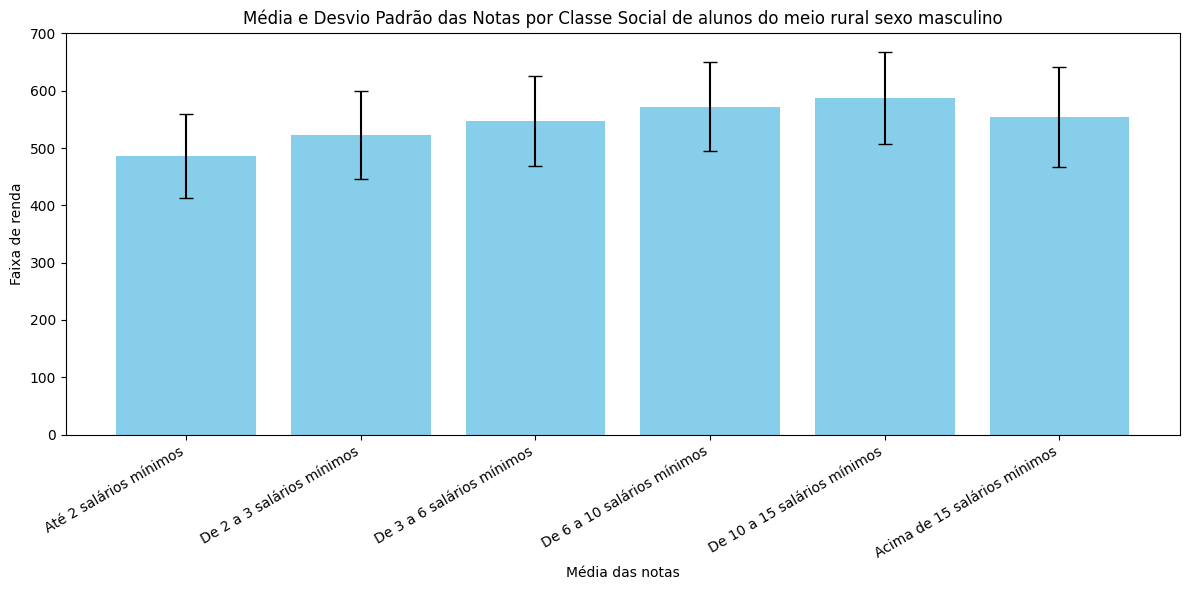

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,486.789219,499.950000,73.325279,5376.596599,437.365000,519.979717,154.320000,739.94,585.620000,15.063045,1
3,De 2 a 3 salários mínimos,522.632271,519.979717,76.427847,5841.215836,472.965000,572.630000,200.189533,734.38,534.190467,14.623637,2
4,De 3 a 6 salários mínimos,547.059438,541.920000,77.912927,6070.424208,498.555000,603.375000,308.620000,746.26,437.640000,14.242132,3
5,De 6 a 10 salários mínimos,572.456040,573.800000,77.299166,5975.160996,519.979717,627.700000,352.469533,756.56,404.090467,13.503075,4
2,De 10 a 15 salários mínimos,587.352991,598.920000,80.338691,6454.305306,532.145000,642.335000,368.400000,766.68,398.280000,13.678093,5
0,Acima de 15 salários mínimos,554.021092,533.620000,86.915669,7554.333580,495.360000,610.040000,381.100000,751.66,370.560000,15.688152,6


In [43]:
analisar_desempenho_por_classe(dataset_rural_homem, "de alunos do meio rural sexo masculino")

In [44]:
modelo_rural_mulher, clf_rural_mulher = treinar_modelo(dataset_rural_mulher)

Acurácia: 0.9975009530263882

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        24
      Até 2 salários mínimos       1.00      1.00      1.00     19835
 De 10 a 15 salários mínimos       1.00      1.00      1.00        60
   De 2 a 3 salários mínimos       1.00      0.98      0.99      1432
   De 3 a 6 salários mínimos       1.00      0.99      0.99      1998
  De 6 a 10 salários mínimos       1.00      1.00      1.00       260

                    accuracy                           1.00     23609
                   macro avg       1.00      0.99      1.00     23609
                weighted avg       1.00      1.00      1.00     23609


Matriz de confusão:
 [[   24     0     0     0     0     0]
 [    0 19835     0     0     0     0]
 [    0     0    60     0     0     0]
 [    0    34     0  1398     0     0]
 [    0    22     0     2  1974     0]
 [    0     1     0  

Importância das features (agregada):
Feature Q010: 0.1450
Feature num__NU_NOTA_LC: 0.1275
Feature num__NU_NOTA_CN: 0.1166
Feature num__NU_NOTA_CH: 0.1022
Feature num__NU_NOTA_MT: 0.0995
Feature num__NU_NOTA_REDACAO: 0.0694
Feature Q008: 0.0481
Feature Q009: 0.0355
Feature num__TP_COR_RACA: 0.0304
Feature num__TP_FAIXA_ETARIA: 0.0291
Feature Q011: 0.0290
Feature Q013: 0.0274
Feature Q019: 0.0261
Feature Q014: 0.0246
Feature Q016: 0.0171
Feature Q015: 0.0163
Feature Q018: 0.0149
Feature Q007: 0.0102
Feature Q012: 0.0087
Feature num__TP_ESTADO_CIVIL: 0.0071


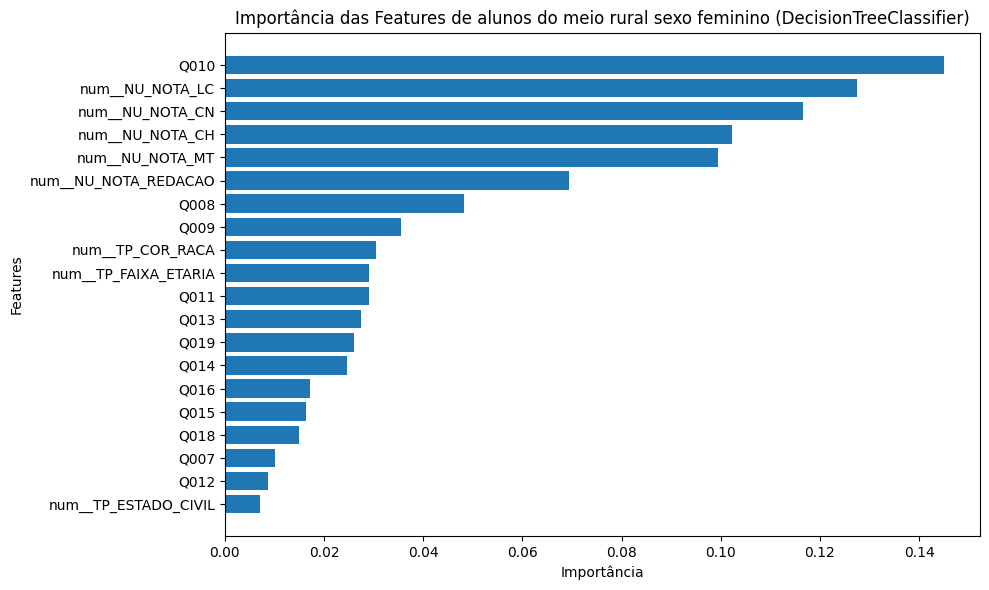

In [45]:
df_importancia_rural_mulher = analisar_importancia_features_agregada(modelo_rural_mulher,clf_rural_mulher, "de alunos do meio rural sexo feminino", top_n=20)

Importância das features (sem agregação):
cat__Q010_A: 0.1352
num__NU_NOTA_LC: 0.1275
num__NU_NOTA_CN: 0.1166
num__NU_NOTA_CH: 0.1022
num__NU_NOTA_MT: 0.0995
num__NU_NOTA_REDACAO: 0.0694
cat__Q008_B: 0.0376
num__TP_COR_RACA: 0.0304
num__TP_FAIXA_ETARIA: 0.0291
cat__Q014_A: 0.0201
cat__Q009_D: 0.0138
cat__Q011_A: 0.0127
cat__Q009_C: 0.0125
cat__Q013_A: 0.0117
cat__Q016_A: 0.0108
cat__Q013_B: 0.0102
cat__Q011_B: 0.0102
cat__Q019_B: 0.0087
cat__Q018_A: 0.0082
cat__Q015_B: 0.0081


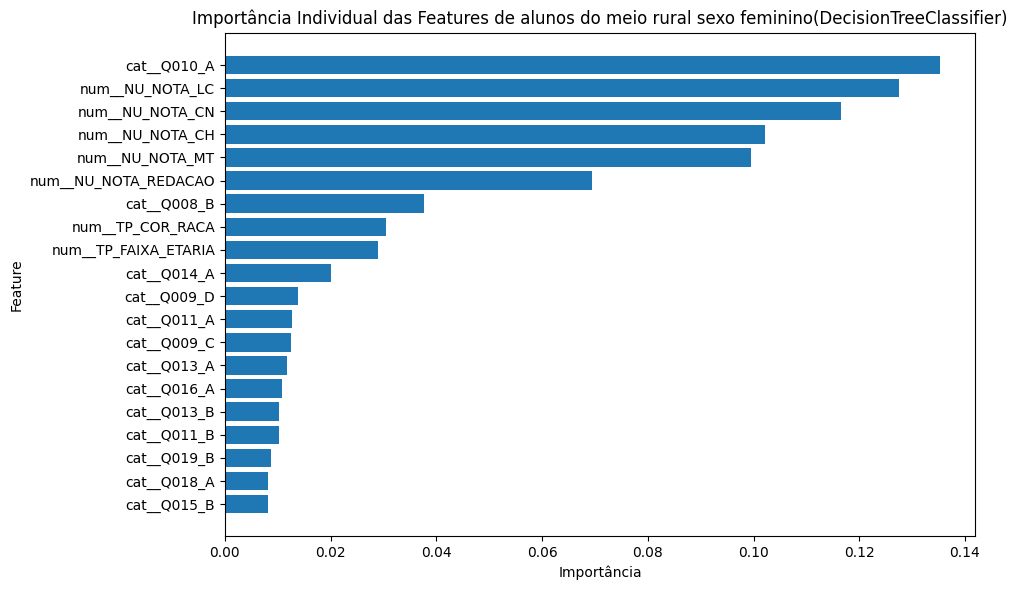

In [46]:
df_importancias_individuais_rural_mulher = analisar_importancia_features(modelo_rural_mulher, clf_rural_mulher, "de alunos do meio rural sexo feminino", top_n=20)


Resumo estatístico completo por classe social de alunos do meio rural sexo feminino:
               classe_social      media    mediana  desvio_padrao   variancia         q1         q3  valor_minimo  valor_maximo  amplitude  coef_var
      Até 2 salários mínimos 485.392326 491.500000      65.519902 4292.857577 442.290000 519.979717    200.189533        769.96 569.770467 13.498339
   De 2 a 3 salários mínimos 525.763225 519.979717      66.891022 4474.408798 481.395000 565.740000    291.160000        729.86 438.700000 12.722651
   De 3 a 6 salários mínimos 551.073805 547.440000      72.195367 5212.170990 505.400000 602.890000    162.800000        741.06 578.260000 13.100853
  De 6 a 10 salários mínimos 576.476134 580.900000      84.307023 7107.674152 519.979717 637.775000    200.189533        753.50 553.310467 14.624547
 De 10 a 15 salários mínimos 572.875643 578.600000      65.412887 4278.845770 526.845000 610.555000    400.780000        705.54 304.760000 11.418340
Acima de 15 salários

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14516\4091095090.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)


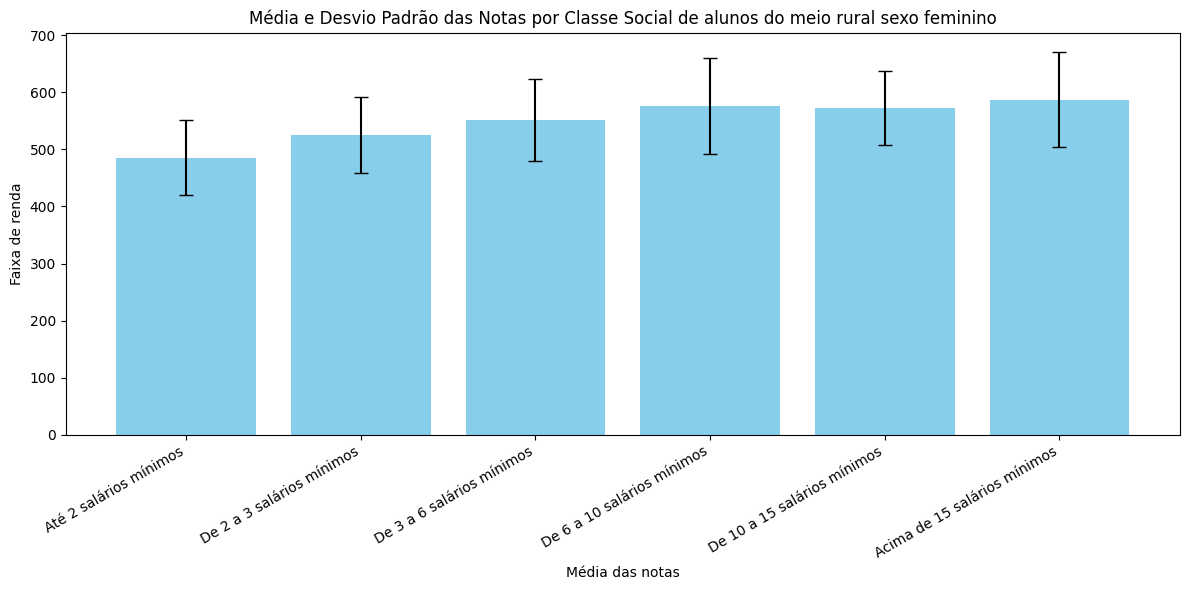

,classe_social,media,mediana,desvio_padrao,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem
1,Até 2 salários mínimos,485.392326,491.500000,65.519902,4292.857577,442.290000,519.979717,200.189533,769.96,569.770467,13.498339,1
3,De 2 a 3 salários mínimos,525.763225,519.979717,66.891022,4474.408798,481.395000,565.740000,291.160000,729.86,438.700000,12.722651,2
4,De 3 a 6 salários mínimos,551.073805,547.440000,72.195367,5212.170990,505.400000,602.890000,162.800000,741.06,578.260000,13.100853,3
5,De 6 a 10 salários mínimos,576.476134,580.900000,84.307023,7107.674152,519.979717,637.775000,200.189533,753.50,553.310467,14.624547,4
2,De 10 a 15 salários mínimos,572.875643,578.600000,65.412887,4278.845770,526.845000,610.555000,400.780000,705.54,304.760000,11.418340,5
0,Acima de 15 salários mínimos,587.452488,623.670000,83.478688,6968.691326,535.489929,651.720000,405.240000,695.54,290.300000,14.210288,6


In [47]:
analisar_desempenho_por_classe(dataset_rural_mulher, "de alunos do meio rural sexo feminino")